<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/AST_Script_TP2_Grupo2_VPS_W_E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N° 2 — Análisis de Series Temporales

## Modelos de Machine Learning para el pronóstico de los ingresos diarios de taxis verdes y Uber en Williamsburg y Midtown Center, Nueva York

**Maestría en Ciencia de Datos — Universidad Austral**

Materia: Análisis de Series Temporales

— Docentes: Rodrigo Del Rosso, Sebastián Calcagno, Braian Drago

Integrantes del grupo:
- Cacabelos, Martín
- Maxwell, Julia
- Nuñez, Keiver
- Sandagorda, Patricia
- Tello, Carmen

---


### Configuración del entorno, conexión a Google Drive y carga de librerías

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    EN_COLAB = True
except ImportError:
    EN_COLAB = False
    print("Entorno local detectado: se omite el montaje de Google Drive.")

Mounted at /content/drive


In [ ]:
!pip install great_tables --break-system-packages
!pip install pmdarima --break-system-packages
!pip install optuna
!pip install lightgbm
!pip install xgboost
!pip install holidays
!pip install arch -q
!pip install great_tables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.4/495.4 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 6.1 MB/s eta 0:00:00


In [ ]:
import pathlib

COLAB_DIR = pathlib.Path('/content/drive/MyDrive/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Final')
LOCAL_DIR = pathlib.Path('G:/Mi unidad/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Final')
DATA_FOLDER = 'data'

if EN_COLAB:
    DATA_DIR = COLAB_DIR / DATA_FOLDER
else:
    DATA_DIR = LOCAL_DIR / DATA_FOLDER

RAW_DIR = DATA_DIR / 'raw'

ARCHIVOS = {
    'taxi_verde_williamsburg': [
        RAW_DIR / 'green_taxi_williamsburg_trips_24-25.csv',
        RAW_DIR / 'green_taxi_williamsburg_trips_25-26.csv',
    ],
    'uber_williamsburg': [
        RAW_DIR / 'uber_williamsburg_trips_24-25.csv',
        RAW_DIR / 'uber_williamsburg_trips_25-26.csv',
    ],
    'uber_midtown': [
        RAW_DIR / 'uber_midtown_center_trips_24-25.csv',
        RAW_DIR / 'uber_midtown_center_trips_25-26.csv',
    ],
}

for nombre, rutas in ARCHIVOS.items():
    for ruta in rutas:
        estado = 'OK' if ruta.exists() else 'NO ENCONTRADO'
        print(f"  {nombre}: {ruta.name} [{estado}]")

  taxi_verde_williamsburg: green_taxi_williamsburg_trips_24-25.csv [OK]
  taxi_verde_williamsburg: green_taxi_williamsburg_trips_25-26.csv [OK]
  uber_williamsburg: uber_williamsburg_trips_24-25.csv [OK]
  uber_williamsburg: uber_williamsburg_trips_25-26.csv [OK]
  uber_midtown: uber_midtown_center_trips_24-25.csv [OK]
  uber_midtown: uber_midtown_center_trips_25-26.csv [OK]


In [ ]:
if not DATA_DIR.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Directorio '{DATA_DIR}' creado.")
else:
    print(f"Directorio '{DATA_DIR}' ya existe.")

print(f"Contenido de {DATA_DIR}:")
for item in sorted(DATA_DIR.iterdir()):
    print(' ', item.name)

Directorio '/content/drive/MyDrive/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Final/data' ya existe.
Contenido de /content/drive/MyDrive/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Final/data:
  busqueda_ljungbox_taxi_verde_williamsburg.csv
  busqueda_ljungbox_uber_midtown.csv
  busqueda_ljungbox_uber_williamsburg.csv
  comparacion_benchmark_sarimax.csv
  gridsearch
  ingresos_diarios.csv
  ml_experimentos
  optuna
  raw


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

### Construcción de la serie diaria de ingresos (01/06/2024 – 31/05/2026)

In [ ]:
FECHA_INICIO = '2024-06-01'
FECHA_FIN = '2026-05-31'
RANGO_FECHAS = pd.date_range(FECHA_INICIO, FECHA_FIN, freq='D')

RUTA_CACHE = DATA_DIR / 'ingresos_diarios.csv'
FORZAR_RECALCULO = False  # cambiar a True si se modifican los CSV originales


def ingreso_diario(rutas_csv, columna_valor, columna_fecha='pickup_date', chunksize=250_000):
    """Agrega por día, en bloques, la columna monetaria indicada.

    Admite una ruta única o una lista de rutas (distintos vintages del mismo
    recorte geográfico), que se concatenan antes de reindexar contra el
    rango de fechas completo.
    """
    if isinstance(rutas_csv, (str, pathlib.Path)):
        rutas_csv = [rutas_csv]

    acumulado = pd.Series(0.0, index=RANGO_FECHAS)
    for ruta_csv in rutas_csv:
        lector = pd.read_csv(
            ruta_csv,
            usecols=[columna_fecha, columna_valor],
            parse_dates=[columna_fecha],
            chunksize=chunksize,
        )
        for bloque in lector:
            suma_bloque = bloque.groupby(columna_fecha)[columna_valor].sum()
            acumulado = acumulado.add(suma_bloque, fill_value=0.0)
    return acumulado.reindex(RANGO_FECHAS, fill_value=0.0)


if RUTA_CACHE.exists() and not FORZAR_RECALCULO:
    ingresos = pd.read_csv(RUTA_CACHE, index_col=0, parse_dates=True)
else:
    ingresos = pd.DataFrame({
        'taxi_verde_williamsburg': ingreso_diario(ARCHIVOS['taxi_verde_williamsburg'], 'total_amount'),
        'uber_williamsburg': ingreso_diario(ARCHIVOS['uber_williamsburg'], 'costo_total'),
        'uber_midtown': ingreso_diario(ARCHIVOS['uber_midtown'], 'costo_total'),
    })
    ingresos.index.name = 'fecha'
    ingresos.to_csv(RUTA_CACHE)

ingresos.index.name = 'fecha'
print(f"Serie construida: {ingresos.shape[0]} días, {ingresos.shape[1]} series")
ingresos.head()

Serie construida: 730 días, 3 series


,taxi_verde_williamsburg,uber_williamsburg,uber_midtown
fecha,,,
2024-06-01,291.40,"339,938.85","162,255.10"
2024-06-02,480.02,"254,645.27","113,694.65"
2024-06-03,0.00,"106,596.77","280,473.49"
2024-06-04,72.30,"105,553.50","408,520.92"
2024-06-05,88.96,"124,873.13","477,617.80"


In [ ]:
DATA_PATH = DATA_DIR / 'ingresos_diarios.csv'
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
df = df.asfreq('D')

assert df.index.min() == pd.Timestamp(FECHA_INICIO) and df.index.max() == pd.Timestamp(FECHA_FIN), \
    'El rango de fechas cargado no coincide con el esperado (2024-06-01 a 2026-05-31).'

df.head()

,taxi_verde_williamsburg,uber_williamsburg,uber_midtown
fecha,,,
2024-06-01,291.40,"339,938.85","162,255.10"
2024-06-02,480.02,"254,645.27","113,694.65"
2024-06-03,0.00,"106,596.77","280,473.49"
2024-06-04,72.30,"105,553.50","408,520.92"
2024-06-05,88.96,"124,873.13","477,617.80"


#### Gráfico 1. Evolución temporal y medias/varianzas móviles a 7 días de los ingresos totales de Uber en Williamsburg y en Midtown Center, y de Taxi Verde en Williamsburg, 06/2024–05/2026

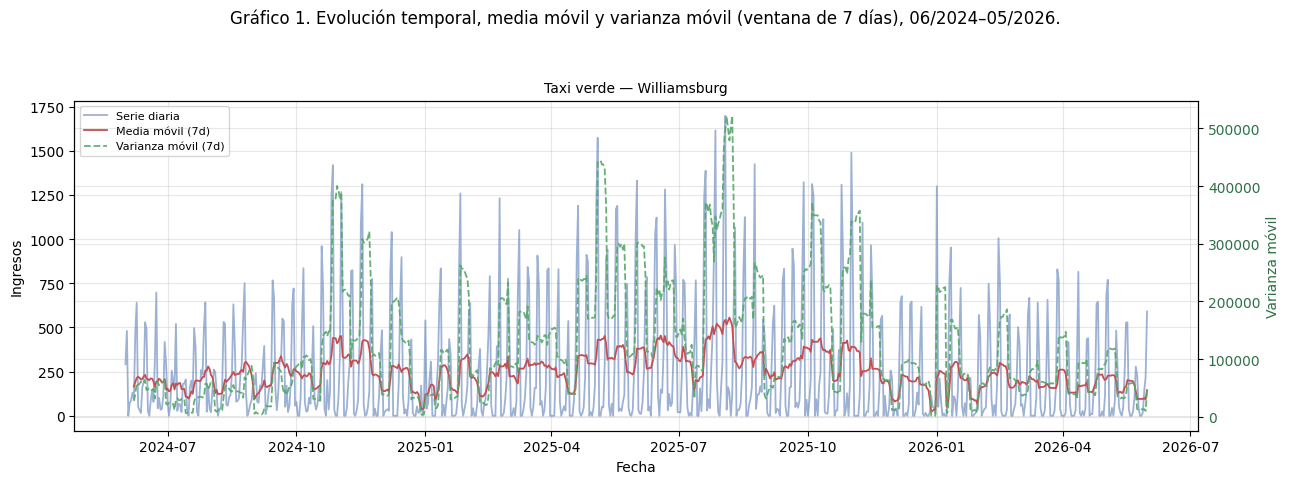

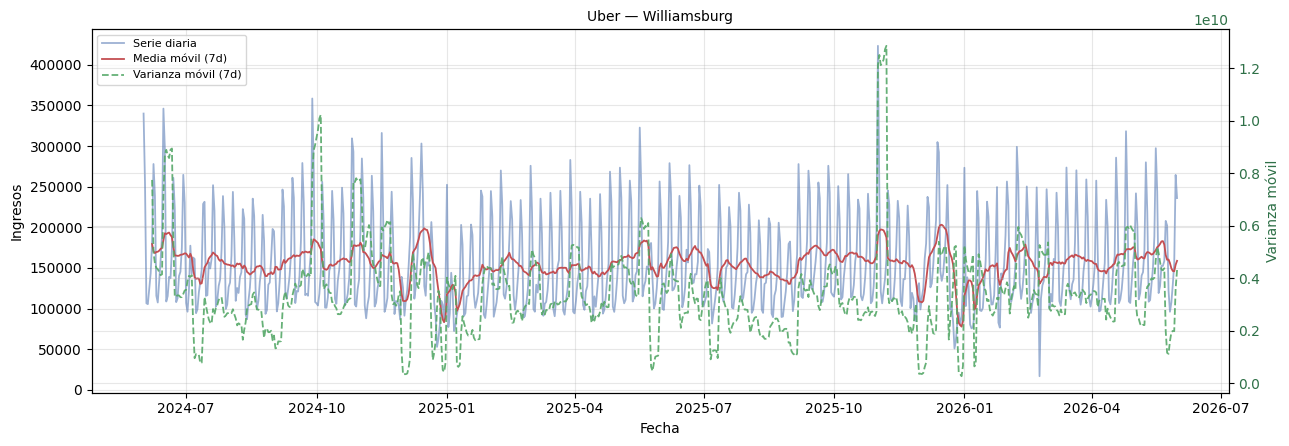

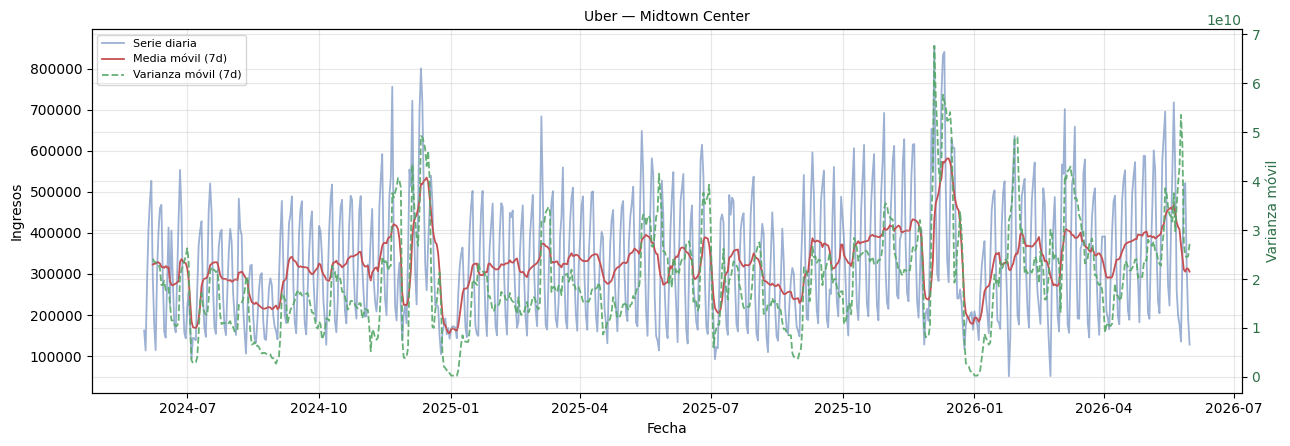

In [ ]:
columnas = {
    'taxi_verde_williamsburg': 'Taxi verde — Williamsburg',
    'uber_williamsburg': 'Uber — Williamsburg',
    'uber_midtown': 'Uber — Midtown Center',
}

VENTANA = 7

for idx, (col, titulo) in enumerate(columnas.items()):
    serie = df[col]
    media_movil = serie.rolling(VENTANA).mean()
    var_movil = serie.rolling(VENTANA).var()

    fig, ax1 = plt.subplots(figsize=(13, 4.8))
    if idx == 0:
        fig.suptitle('Gráfico 1. Evolución temporal, media móvil y varianza móvil (ventana de 7 días), 06/2024–05/2026.',
                     fontsize=12, y=1.0)

    ax1.plot(serie.index, serie.values, lw=1.3, alpha=0.55, color='#4C72B0', label='Serie diaria')
    ax1.plot(serie.index, media_movil, lw=1.3, color='#C44E52', label=f'Media móvil ({VENTANA}d)')
    ax1.set_ylabel('Ingresos')
    ax1.set_xlabel('Fecha')

    ax2 = ax1.twinx()
    ax2.plot(serie.index, var_movil, lw=1.3, color='#55A868', alpha=0.9,
              linestyle='--', label=f'Varianza móvil ({VENTANA}d)')
    ax2.set_ylabel('Varianza móvil', color='#2E7047')
    ax2.tick_params(axis='y', labelcolor='#2E7047')

    lineas1, etiquetas1 = ax1.get_legend_handles_labels()
    lineas2, etiquetas2 = ax2.get_legend_handles_labels()
    ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper left', fontsize=8)

    ax1.set_title(titulo, fontsize=10)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

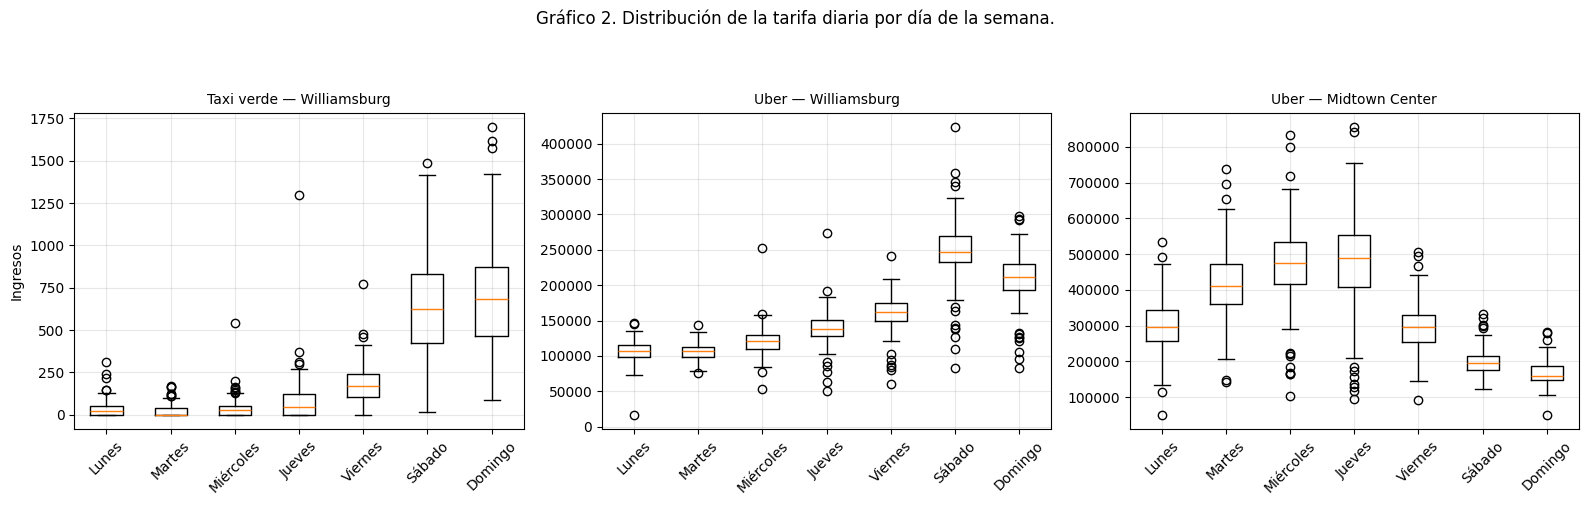

In [ ]:
dias_orden = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('Gráfico 2. Distribución de la tarifa diaria por día de la semana.',
             fontsize=12,  y=1)

for i, (col, titulo) in enumerate(columnas.items()):
    serie = df[col]
    tmp = pd.DataFrame({
        'valor': serie.values,
        'dia_semana': serie.index.dayofweek,
    })
    tmp['dia_semana'] = tmp['dia_semana'].map(dict(enumerate(dias_orden)))

    ax = axes[i]
    data_dia = [tmp.loc[tmp['dia_semana'] == d, 'valor'] for d in dias_orden]
    ax.boxplot(data_dia, tick_labels=dias_orden)
    ax.set_title(titulo, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    if i == 0:
        ax.set_ylabel('Ingresos')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

WINDOW_SIZE = 7  # fijo — no lo cambies entre corridas si querés comparar resultados


def analyze_rango_mediana(series, window_size=WINDOW_SIZE):
    """
    Divide la serie en subgrupos, calcula rango y mediana,
    y ajusta: ln(Rango) = a + b * ln(Mediana)
    Descarta subgrupos con mediana o rango <= 0 (no admiten logaritmo).
    """
    n = len(series)
    num_groups = n // window_size
    medianas, rangos = [], []

    for i in range(num_groups):
        subgroup = series[i * window_size : (i + 1) * window_size]
        medianas.append(np.median(subgroup))
        rangos.append(np.max(subgroup) - np.min(subgroup))

    medianas, rangos = np.array(medianas), np.array(rangos)

    # filtro: descartar subgrupos no aptos para log
    mask = (medianas > 0) & (rangos > 0)
    n_descartados = (~mask).sum()
    if n_descartados > 0:
        print(f'  [aviso] se descartaron {n_descartados} de {len(medianas)} subgrupos por mediana o rango <= 0')
    medianas, rangos = medianas[mask], rangos[mask]

    log_medianas, log_rangos = np.log(medianas), np.log(rangos)
    slope, intercept = np.polyfit(log_medianas, log_rangos, 1)

    y_pred = slope * log_medianas + intercept
    r_squared = 1 - (np.sum((log_rangos - y_pred) ** 2) / np.sum((log_rangos - np.mean(log_rangos)) ** 2))

    return {
        'medianas': medianas, 'rangos': rangos, 'intercept': intercept,
        'slope': slope, 'r_squared': r_squared, 'lambda_empirico': 1 - slope,
    }


def calcular_shift(series, margen=1.0):
    """Shift fijo y explícito para series con valores <= 0 (Box-Cox lo requiere)."""
    minimo = np.min(series)
    return (-minimo + margen) if minimo <= 0 else 0.0


def get_boxcox_ci(series, alpha=0.05):
    """
    Lambda óptimo por MLE y su IC al (1-alpha) usando scipy.stats.boxcox.
    Aplica shift automáticamente si la serie tiene valores <= 0.
    """
    shift = calcular_shift(series)
    series_shifted = np.array(series) + shift

    _, l_opt, ci = boxcox(series_shifted, alpha=alpha)
    ci_lower, ci_upper = ci

    return l_opt, ci_lower, ci_upper, shift

# --- Cálculo consolidado para las tres series ---

filas = []
detalle_grafico = {}

for col, titulo in columnas.items():
    serie_valores = df[col].dropna().values

    rm = analyze_rango_mediana(serie_valores, window_size=WINDOW_SIZE)
    l_opt, ci_inf, ci_sup, shift = get_boxcox_ci(serie_valores)

    filas.append({
        'Serie': titulo,
        'Pendiente (b)': rm['slope'],
        'R² (Ajuste empírico)': rm['r_squared'],
        'Lambda Empírico (1-b)': rm['lambda_empirico'],
        'Lambda Óptimo (MLE)': l_opt,
        'IC 95% Inferior': ci_inf,
        'IC 95% Superior': ci_sup,
    })

    detalle_grafico[col] = {**rm, 'titulo': titulo}

tabla_resultados = pd.DataFrame(filas)

from great_tables import GT, style, loc, md

tabla_gt = (
    GT(tabla_resultados)
    .tab_header(
        title=f'Tabla 1. Estabilización de varianza: Rango-Mediana (ventana={WINDOW_SIZE}) vs. Box-Cox MLE'
    )
    .fmt_number(
        columns=['Pendiente (b)', 'R² (Ajuste empírico)', 'Lambda Empírico (1-b)',
                 'Lambda Óptimo (MLE)', 'IC 95% Inferior', 'IC 95% Superior'],
        decimals=3
    )
    .cols_label(
        **{
            'Pendiente (b)': md('Pendiente<br>(b)'),
            'R² (Ajuste empírico)': md('R²<br>(ajuste empírico)'),
            'Lambda Empírico (1-b)': md('λ empírico<br>(1-b)'),
            'Lambda Óptimo (MLE)': md('λ óptimo<br>(MLE)'),
            'IC 95% Inferior': md('IC 95%<br>inferior'),
            'IC 95% Superior': md('IC 95%<br>superior'),
        }
    )
    .tab_style(
        style=style.text(weight='bold'),
        locations=loc.body(columns='Serie')
    )
)

tabla_gt

  [aviso] se descartaron 4 de 104 subgrupos por mediana o rango <= 0


GT(_tbl_data=                       Serie  Pendiente (b)  R² (Ajuste empírico)  \
0  Taxi verde — Williamsburg           0.09                  0.02   
1        Uber — Williamsburg           0.36                  0.03   
2      Uber — Midtown Center           1.40                  0.59   

   Lambda Empírico (1-b)  Lambda Óptimo (MLE)  IC 95% Inferior  \
0                   0.91                 0.16             0.12   
1                   0.64                -0.02            -0.15   
2                  -0.40                 0.23             0.08   

   IC 95% Superior  
0             0.19  
1             0.12  
2             0.39  , _body=<great_tables._gt_data.Body object at 0x7a0c7e4e7a10>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Pendiente (b)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Pendiente<br>(b)'), column_align='right', column_width=None), ColInfo(var='R² (Ajuste empírico)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='R²<br>(ajuste empírico)'), column_align='right', column_width=None), ColInfo(var='Lambda Empírico (1-b)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='λ empírico<br>(1-b)'), column_align='right', column_width=None), ColInfo(var='Lambda Óptimo (MLE)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='λ óptimo<br>(MLE)'), column_align='right', column_width=None), ColInfo(var='IC 95% Inferior', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='IC 95%<br>inferior'), column_align='right', column_width=None), ColInfo(var='IC 95% Superior', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='IC 95%<br>superior'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7a0c7e4e7770>, _spanners=Spanners([]), _heading=Heading(title='Tabla 1. Estabilización de varianza: Rango-Mediana (ventana=7) vs. Box-Cox MLE', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7a0c7e4e7e00>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7a0c7e49f390>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7a0c7e3d4050>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7a0c7e4e7cb0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInf

In [ ]:
columnas = {
    'taxi_verde_williamsburg': 'Taxi verde — Williamsburg',
    'uber_williamsburg': 'Uber — Williamsburg',
    'uber_midtown': 'Uber — Midtown Center',
}


### Variables exógenas de calendario

Las series analizadas exhiben, según lo relevado en el TP1, una estacionalidad semanal marcada —de signo opuesto entre Williamsburg y Midtown Center— y posibles efectos de fin de mes, de temporada y de fechas particulares del calendario neoyorquino. Con el objetivo de que tanto el benchmark SARIMAX como los modelos de aprendizaje automático dispongan de la misma información de calendario, se construye a continuación un conjunto común de variables exógenas:

- **día del año** (`dayofyear`, 1–366),
- **día del mes** (`dayofmonth`, 1–31),
- **día de la semana** (`dayofweek`, 0 = lunes … 6 = domingo),
- **semana del año** (`weekofyear`, según el calendario ISO),
- **mes del año** (`month`, 1–12),
- **trimestre** (`quarter`, 1–4),
- **año** (`year`), para captar un eventual efecto de nivel o tendencia entre 2024, 2025 y 2026,
- **feriado** (`holiday`), indicador binario construido a partir del calendario de feriados de Estados Unidos correspondientes al estado de Nueva York (paquete `holidays`, `country_holidays('US', subdiv='NY')`), dado que las tres series corresponden a viajes realizados dentro de la ciudad de Nueva York.

Estas variables se incorporan aquí en su forma "cruda"; la codificación específica que recibe cada una (variables dummy para el SARIMAX, codificación categórica o numérica para los ensambles de árboles) se define en la sección correspondiente a cada familia de modelos. A continuación se suman, exclusivamente para LightGBM y XGBoost, variables autorregresivas construidas a partir del propio target (rezagos y estadísticos móviles).

In [ ]:
import holidays

ANIOS = range(df.index.year.min(), df.index.year.max() + 1)
feriados_us_ny = holidays.country_holidays('US', subdiv='NY', years=list(ANIOS))

exog_calendario = pd.DataFrame(index=df.index)

exog_calendario['dayofyear'] = df.index.dayofyear
exog_calendario['dayofmonth'] = df.index.day
exog_calendario['dayofweek'] = df.index.dayofweek
exog_calendario['weekofyear'] = df.index.isocalendar().week.astype(int).values
exog_calendario['month'] = df.index.month
exog_calendario['quarter'] = df.index.quarter
exog_calendario['year'] = df.index.year
exog_calendario['holiday'] = [int(fecha in feriados_us_ny) for fecha in df.index.date]

print(f"Feriados US/NY identificados en el período ({FECHA_INICIO} a {FECHA_FIN}): {exog_calendario['holiday'].sum()} días")
exog_calendario.head()


Feriados US/NY identificados en el período (2024-06-01 a 2026-05-31): 28 días


,dayofyear,dayofmonth,dayofweek,weekofyear,month,quarter,year,holiday
fecha,,,,,,,,
2024-06-01,153,1,5,22,6,2,2024,0
2024-06-02,154,2,6,22,6,2,2024,0
2024-06-03,155,3,0,23,6,2,2024,0
2024-06-04,156,4,1,23,6,2,2024,0
2024-06-05,157,5,2,23,6,2,2024,0


### Variables autorregresivas (rezagos y estadísticos móviles)

Además de las variables de calendario, LightGBM y XGBoost incorporan variables construidas a partir de los valores pasados de cada serie, dado que son el principal mecanismo con el que estos modelos —a diferencia del SARIMAX, que modela la autocorrelación explícitamente a través de sus componentes AR/MA— pueden capturar la dependencia temporal. Se agregan dos familias de variables:

- **Rezagos** (`lag_k`): el valor de la propia serie `k` días atrás. Se incluyen `k = 1, 2, 7, 14, 21, 28`: los rezagos cortos (1 y 2) capturan la inercia de corto plazo, mientras que los múltiplos de siete (7, 14, 21, 28) apuntan directamente a la estacionalidad semanal identificada en el TP1 (hasta cuatro semanas hacia atrás).
- **Estadísticos móviles** (`rolling_mean_w`, `rolling_std_w`): media y desvío estándar sobre ventanas de `w = 7, 14, 28` días, análogos a la media y varianza móvil ya graficadas en el Gráfico 1, pero pensados como *features* de nivel y de volatilidad reciente.

Un punto importante es que, para el día `t`, ninguna de estas variables puede utilizar información de `t` en adelante: los rezagos ya son estrictamente pasados por construcción, y los estadísticos móviles se calculan sobre la serie desplazada un día (`shift(1)`) antes de aplicar la ventana, de forma que `rolling_mean_7` en `t` resuma los días `t-7` a `t-1`. Esto es lo que después permite pronosticar el mes de test de forma recursiva: al proyectar el día `t`, los rezagos y estadísticos móviles se recalculan usando los valores ya pronosticados para los días anteriores del propio horizonte de test.

Como contrapartida, los primeros `28` días de la muestra (el rezago y la ventana más largos) quedan con algún `NaN` en estas columnas y se descartan del entrenamiento; con 730 observaciones totales la pérdida es marginal.

In [ ]:
LAGS = [1, 2, 7, 14, 21, 28, 30, 35]
VENTANAS_ROLLING = [7, 14, 28, 35]


def agregar_features_autorregresivas(serie, lags=LAGS, ventanas=VENTANAS_ROLLING):
    """
    Construye rezagos y estadísticos móviles (media, desvío) de `serie`.
    Los estadísticos móviles se calculan sobre la serie desplazada un día
    (shift(1)) antes de aplicar la ventana, de forma que en `t` solo resuman
    información hasta `t-1` (sin leakage).
    """
    feats = pd.DataFrame(index=serie.index)

    for lag in lags:
        feats[f'lag_{lag}'] = serie.shift(lag)

    serie_desplazada = serie.shift(1)
    for ventana in ventanas:
        rolling = serie_desplazada.rolling(ventana)
        feats[f'rolling_mean_{ventana}'] = rolling.mean()
        feats[f'rolling_std_{ventana}'] = rolling.std()

    return feats


features_por_serie = {}

for col in columnas:
    feats_autorregresivas = agregar_features_autorregresivas(df[col])
    features_completas = exog_calendario.join(feats_autorregresivas)
    features_completas[col] = df[col]  # target al final, solo de referencia
    features_por_serie[col] = features_completas

    print(f"{col}: {features_completas.shape[0]} filas, {features_completas.shape[1] - 1} features "
          f"(+ target) | filas con algún NaN: {features_completas.drop(columns=col).isna().any(axis=1).sum()}")

# Vista de ejemplo: Uber - Midtown Center, ya sin los NaN iniciales
features_por_serie['uber_midtown'].dropna().head()

taxi_verde_williamsburg: 730 filas, 24 features (+ target) | filas con algún NaN: 35
uber_williamsburg: 730 filas, 24 features (+ target) | filas con algún NaN: 35
uber_midtown: 730 filas, 24 features (+ target) | filas con algún NaN: 35


,dayofyear,dayofmonth,dayofweek,weekofyear,month,quarter,year,holiday,lag_1,lag_2,...,lag_35,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28,rolling_mean_35,rolling_std_35,uber_midtown
fecha,,,,,,,,,,,,,,,,,,,,,
2024-07-06,188,6,5,27,7,3,2024,0,"144,385.91","93,629.60",...,"162,255.10","170,764.71","53,208.45","250,810.83","136,690.93","272,733.80","128,398.82","282,777.42","133,319.28","143,087.21"
2024-07-07,189,7,6,27,7,3,2024,0,"143,087.21","144,385.91",...,"113,694.65","168,782.56","54,059.95","248,446.42","138,357.13","271,574.40","129,451.12","282,229.76","133,867.17","138,488.60"
2024-07-08,190,8,0,28,7,3,2024,0,"138,488.60","143,087.21",...,"280,473.49","168,094.30","54,467.48","247,063.28","139,425.12","272,430.24","128,449.70","282,938.16","133,011.96","261,877.44"
2024-07-09,191,9,1,28,7,3,2024,0,"261,877.44","138,488.60",...,"408,520.92","174,411.62","63,060.52","244,381.63","138,699.80","270,876.16","128,299.29","282,406.85","133,059.22","369,381.77"
2024-07-10,192,10,2,28,7,3,2024,0,"369,381.77","261,877.44",...,"477,617.80","190,837.57","94,504.22","239,932.78","133,117.03","269,649.02","127,140.49","281,288.59","132,129.38","405,516.97"


## Benchmark estadístico: SARIMAX

Con la historia extendida a dos años y las variables exógenas de calendario ya construidas, se estima a continuación un modelo **SARIMAX** como benchmark estadístico, siguiendo la misma lógica metodológica de los puntos 6 a 8 del TP1 (gridsearch con caché, selección por AIC/BIC en train, evaluación de MAE/RMSE en test), pero incorporando exógenas. Para que la comparación aísle el aporte de la estructura ARIMA en sí —y no solo el de las exógenas—, se corre el mismo gridsearch para cuatro familias, todas con las mismas variables exógenas: **SARIMAX** (con componente estacional semanal, `s=7`), **ARIMAX** (sin componente estacional), **ARX** y **MAX** (casos particulares del ARIMAX con solo autorregresivo o solo medias móviles, respectivamente). El SARIMAX es el benchmark propiamente dicho; las otras tres familias cumplen el mismo rol que ARIMA/AR/MA en el TP1, es decir, contextualizar qué tanto aporta la parte estacional.

**Variables exógenas utilizadas.** De las variables de calendario construidas más arriba se seleccionan solo dos, tras un diagnóstico empírico (celda siguiente):

- `holiday` (indicador de feriado US/NY), para captar efectos de días puntuales.
- `year` (como dummies, 2 columnas), para permitir un quiebre de nivel entre 2024, 2025 y 2026 —coincide, por ejemplo, con la entrada en vigencia de la *Congestion Relief Zone* el 5 de enero de 2025 mencionada en la introducción del TP1—.

En un primer intento se había incorporado también `month` (11 dummies) para captar la estacionalidad anual que el componente estacional del SARIMAX (`s=7`, semanal) no cubre. Sin embargo, al comparar el desempeño en test se observó que agregar `month` **empeora sustancialmente** el pronóstico en las tres series (por ejemplo, en Uber Williamsburg el RMSE pasa de ~19.100 sin `month` a ~41.700 con `month`, para el mismo orden SARIMAX). La razón es que, con solo dos años de historia, cada nivel de `month` está representado por apenas una o dos observaciones previas al mes de test, por lo que su coeficiente se estima con muchísima varianza y arruina la extrapolación a mayo de 2026. Una alternativa más suave —términos de Fourier de periodicidad anual— tampoco mejoró el ajuste. Por eso se optó por no incluir ninguna variable de estacionalidad anual explícita y limitar las exógenas a `holiday` y `year`, que en el diagnóstico resultan mejores o equivalentes a no usar exógenas en absoluto. Se excluyen además `dayofweek` (redundante: ya lo captura el componente estacional `(P,D,Q,7)` del propio modelo) y `dayofmonth`/`weekofyear`/`quarter`/`dayofyear` (demasiado granulares).

**Configuración de la búsqueda.** Se reutilizan las transformaciones y los rangos (p,d,q)(P,D,Q) de la Tabla 5 del TP1 como punto de partida —incluida la raíz cuadrada sobre Uber Midtown por su heterocedasticidad—, pero dejando que el propio gridsearch explore tanto `D=0` como `D=1` en las tres series, en lugar de fijar el valor de la Tabla 5 original. Esto se debe a que, en el TP1, el modelo finalmente elegido para cada serie —tanto por desempeño en test como, más adelante, por diagnóstico de residuos— terminó usando un `D` distinto del de esa tabla en los tres casos (Taxi Verde con `D=0`, ambas series de Uber con `D=1`), por lo que fijar un único valor de entrada habría dejado esas alternativas fuera del espacio de búsqueda. La selección de candidatos top-3 se hace además por separado dentro de cada combinación `(d, D)` (ver `top_n_por_diferenciacion` más abajo), precisamente para no perder esas alternativas frente al criterio de AIC, que no es comparable entre series con distinto nivel de diferenciación. A diferencia de la Tabla 7 del TP1, que reportaba el error de Uber Midtown en la escala de raíz cuadrada, aquí la predicción se destransforma (elevando al cuadrado) antes de calcular RMSE y MAE, de modo que las tres series queden expresadas en dólares y sean directamente comparables entre sí y, más adelante, con los modelos de machine learning. El conjunto de test vuelve a ser el último mes calendario completo (mayo de 2026); todo lo demás es train.

In [ ]:
import itertools
import pickle
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.metrics import mean_squared_error, mean_absolute_error
from great_tables import GT, style, loc, md

warnings.filterwarnings('ignore', category=ConvergenceWarning)


def dividir_train_test(serie):
    """
    Divide la serie en train / test usando meses calendario completos:
    - test: último mes calendario presente en la serie (mayo de 2026)
    - train: todo lo anterior a ese mes
    """
    serie = serie.dropna()
    periodos = serie.index.to_period('M')
    ultimo_mes = periodos.max()

    test = serie[periodos == ultimo_mes]
    train = serie[periodos < ultimo_mes]

    return train, test

In [ ]:
def construir_exog_sarimax(exog_calendario):
    """
    Arma la matriz de exógenas para el SARIMAX/ARIMAX/ARX/MAX a partir de
    exog_calendario: dummies de año (quiebres de nivel entre 2024/2025/2026)
    más el indicador de feriado. No se incluye `month`: un diagnóstico
    empírico (ver celda siguiente) mostró que, con solo dos años de historia,
    cada nivel de `month` está representado por apenas 1-2 observaciones
    previas, lo que vuelve inestable su coeficiente y empeora sustancialmente
    el pronóstico fuera de muestra en las tres series. Tampoco se incluyen
    `dayofweek` (redundante con el componente estacional s=7), ni
    `dayofmonth`/`weekofyear`/`quarter`/`dayofyear` (demasiado granulares).
    """
    dummies_year = pd.get_dummies(exog_calendario['year'], prefix='year', drop_first=True, dtype=float)
    holiday = exog_calendario[['holiday']].astype(float)

    exog_sarimax = pd.concat([holiday, dummies_year], axis=1)
    exog_sarimax.index = exog_calendario.index
    return exog_sarimax


exog_sarimax = construir_exog_sarimax(exog_calendario)
print(f"exog_sarimax: {exog_sarimax.shape[0]} filas x {exog_sarimax.shape[1]} columnas")
print(list(exog_sarimax.columns))
exog_sarimax.head()

exog_sarimax: 730 filas x 3 columnas
['holiday', 'year_2025', 'year_2026']


,holiday,year_2025,year_2026
fecha,,,
2024-06-01,0.00,0.00,0.00
2024-06-02,0.00,0.00,0.00
2024-06-03,0.00,0.00,0.00
2024-06-04,0.00,0.00,0.00
2024-06-05,0.00,0.00,0.00


### Diagnóstico: ¿qué exógenas conviene incluir?

Antes de correr el gridsearch completo, se compara —para un orden SARIMAX/ARIMAX de referencia en cada serie— el desempeño en test bajo tres especificaciones de exógenas: sin exógenas, `holiday + month + year` (el conjunto completo inicialmente considerado) y `holiday + year` (sin `month`). El objetivo es decidir, con evidencia, qué variables "sirven" antes de invertir tiempo de cómputo en el gridsearch de las cuatro familias.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Exógenas alternativas, solo para este diagnóstico (no se usan más adelante)
dummies_month_diag = pd.get_dummies(exog_calendario['month'], prefix='month', drop_first=True, dtype=float)
dummies_year_diag = pd.get_dummies(exog_calendario['year'], prefix='year', drop_first=True, dtype=float)
holiday_diag = exog_calendario[['holiday']].astype(float)

exog_variantes = {
    'sin exógenas': None,
    'holiday + month + year': pd.concat([holiday_diag, dummies_month_diag, dummies_year_diag], axis=1),
    'holiday + year (elegida)': pd.concat([holiday_diag, dummies_year_diag], axis=1),
}

# Serie de Uber Midtown en escala sqrt, solo para este diagnóstico
uber_midtown_sqrt_diag = np.sqrt(df['uber_midtown'])

casos_diagnostico = [
    ('taxi_verde_williamsburg', df['taxi_verde_williamsburg'], (1, 0, 1), (0, 1, 2, 7), None),
    ('uber_williamsburg', df['uber_williamsburg'], (1, 0, 2), (1, 0, 2, 7), None),
    ('uber_midtown (sqrt)', uber_midtown_sqrt_diag, (2, 1, 3), (0, 0, 0, 7), df['uber_midtown']),
]

filas_diagnostico = []
for nombre_serie, serie, order, seasonal_order, serie_original in casos_diagnostico:
    train, test = dividir_train_test(serie)
    test_original = None
    if serie_original is not None:
        _, test_original = dividir_train_test(serie_original)

    for nombre_exog, exog in exog_variantes.items():
        exog_train = None if exog is None else exog.loc[train.index]
        exog_test = None if exog is None else exog.loc[test.index]

        modelo = SARIMAX(train, exog=exog_train, order=order, seasonal_order=seasonal_order,
                          enforce_stationarity=False, enforce_invertibility=False)
        fit_obj = modelo.fit(disp=False)
        pred = fit_obj.get_forecast(steps=len(test), exog=exog_test).predicted_mean
        pred.index = test.index

        if test_original is not None:
            pred_eval, objetivo_eval = pred ** 2, test_original
        else:
            pred_eval, objetivo_eval = pred, test

        filas_diagnostico.append({
            'Serie': columnas.get(nombre_serie.split(' ')[0], nombre_serie),
            'Exógenas': nombre_exog,
            'k': 0 if exog is None else exog.shape[1],
            'RMSE': float(np.sqrt(mean_squared_error(objetivo_eval, pred_eval))),
            'MAE': float(mean_absolute_error(objetivo_eval, pred_eval)),
        })

df_diagnostico_exog = pd.DataFrame(filas_diagnostico)
df_diagnostico_exog

,Serie,Exógenas,k,RMSE,MAE
0,Taxi verde — Williamsburg,sin exógenas,0,123.65,71.66
1,Taxi verde — Williamsburg,holiday + month + year,14,154.65,115.53
2,Taxi verde — Williamsburg,holiday + year (elegida),3,124.45,73.63
3,Uber — Williamsburg,sin exógenas,0,"20,086.67","14,868.99"
4,Uber — Williamsburg,holiday + month + year,14,"41,736.45","37,265.42"
5,Uber — Williamsburg,holiday + year (elegida),3,"19,118.52","13,826.80"
6,Uber — Midtown Center,sin exógenas,0,"82,650.06","65,413.17"
7,Uber — Midtown Center,holiday + month + year,14,"82,574.16","67,436.61"
8,Uber — Midtown Center,holiday + year (elegida),3,"76,344.60","61,920.19"


In [ ]:
# Transformación de raíz cuadrada sobre Uber — Midtown Center, reutilizada del TP1
# (λ teórico adoptado = 0.5, por heterocedasticidad moderada)
assert (df['uber_midtown'].dropna() >= 0).all(), 'Hay valores negativos en uber_midtown, no se puede aplicar raíz cuadrada directo'

df_sarimax = df.copy()
df_sarimax['uber_midtown_sqrt'] = np.sqrt(df['uber_midtown'])

# Rangos (p,d,q)(P,D,Q) reutilizados de la Tabla 5 del TP1, dejando que el
# propio gridsearch explore D=0 y D=1 en las tres series: en el TP1, tanto
# Taxi Verde como Uber Williamsburg y Uber Midtown terminaron usando una
# variante D distinta de la de la Tabla 5 original (D=0 para Taxi Verde,
# D=1 para ambas series de Uber en el modelo finalmente elegido tras el
# diagnóstico de residuos), por lo que fijar un único D de entrada dejaba
# esas alternativas fuera del espacio de búsqueda.
configuracion_series = {
    'taxi_verde_williamsburg': {
        'columna_serie': 'taxi_verde_williamsburg',
        'p': (0, 3), 'd': (0, 0), 'q': (0, 1),
        'P': (0, 1), 'D': (0, 1), 'Q': (0, 2),
    },
    'uber_williamsburg': {
        'columna_serie': 'uber_williamsburg',
        'p': (0, 3), 'd': (0, 0), 'q': (0, 2),
        'P': (1, 2), 'D': (0, 1), 'Q': (0, 2),
    },
    'uber_midtown': {
        'columna_serie': 'uber_midtown_sqrt',
        'p': (0, 3), 'd': (0, 0), 'q': (0, 2),
        'P': (1, 2), 'D': (0, 1), 'Q': (0, 2),
    },
}

# Familias comparadas: SARIMAX usa los rangos (P,D,Q) de configuracion_series;
# ARIMAX/ARX/MAX son casos particulares sin componente estacional.
FAMILIAS = {
    'SARIMAX': None,
    'ARIMAX': dict(p=(0, 3), d=(0, 1), q=(0, 3), P=(0, 0), D=(0, 0), Q=(0, 0)),
    'ARX': dict(p=(1, 4), d=(0, 0), q=(0, 0), P=(0, 0), D=(0, 0), Q=(0, 0)),
    'MAX': dict(p=(0, 0), d=(0, 0), q=(1, 4), P=(0, 0), D=(0, 0), Q=(0, 0)),
}

In [ ]:
def sarima_gridsearch(train, s=7, criterio='AIC',
                       p=(0, 3), d=(0, 0), q=(0, 2),
                       P=(0, 1), D=(0, 0), Q=(0, 2),
                       exog=None, verbose=True):
    """
    Búsqueda exhaustiva de hiperparámetros SARIMA/SARIMAX por grid search
    (igual que en el TP1). Ajusta un modelo para cada combinación posible de
    (p,d,q)(P,D,Q,s) dentro de los rangos dados, y evalúa por AIC/BIC. Test
    no participa en ningún momento de esta etapa.
    """
    rangos_p = range(p[0], p[1] + 1)
    rangos_d = range(d[0], d[1] + 1)
    rangos_q = range(q[0], q[1] + 1)
    rangos_P = range(P[0], P[1] + 1)
    rangos_D = range(D[0], D[1] + 1)
    rangos_Q = range(Q[0], Q[1] + 1)

    combinaciones = list(itertools.product(
        rangos_p, rangos_d, rangos_q, rangos_P, rangos_D, rangos_Q
    ))

    if verbose:
        print(f'  Grid search: {len(combinaciones)} combinaciones a evaluar.')

    resultados = []
    for i, (pp, dd, qq, PP, DD, QQ) in enumerate(combinaciones):
        order = (pp, dd, qq)
        seasonal_order = (PP, DD, QQ, s)

        try:
            modelo = SARIMAX(
                train, exog=exog, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False
            )
            fit = modelo.fit(disp=False)
        except Exception:
            continue

        resultados.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'AIC': fit.aic,
            'BIC': fit.bic,
            'LLF': fit.llf,
        })

        if verbose and (i + 1) % 10 == 0:
            print(f'    {i + 1}/{len(combinaciones)} combinaciones evaluadas...')

    df_res = pd.DataFrame(resultados).sort_values(by=criterio).reset_index(drop=True)
    df_res = df_res.drop_duplicates(subset=['order', 'seasonal_order']).reset_index(drop=True)

    if verbose:
        print(f'  Completado: {len(df_res)} modelos válidos de {len(combinaciones)} combinaciones.')

    return df_res

In [ ]:
def top_n_por_diferenciacion(tabla, n=3, criterio='AIC'):
    """
    Selecciona los top-n candidatos por AIC, pero por separado dentro de cada
    combinación (d, D) presente en la tabla. Evita que el AIC —que no es
    comparable entre modelos con distinto nivel de diferenciación— oculte
    candidatos con una diferenciación distinta que generalizan mejor en test.
    Esto es lo que ocurrió en el TP1 con Taxi Verde — Williamsburg: entre los
    modelos con D=1 (mejor AIC) y D=0, fue D=0 el que terminó prediciendo
    mejor sobre el conjunto de test, algo que un top-3 puramente por AIC
    global no habría detectado si D=0 quedaba fuera del podio.
    """
    tabla = tabla.copy()
    tabla['d'] = tabla['order'].apply(lambda o: o[1])
    tabla['D'] = tabla['seasonal_order'].apply(lambda s: s[1])
    return (
        tabla.sort_values(criterio)
        .groupby(['d', 'D'], group_keys=False)
        .head(n)
        .sort_values(criterio)
        .drop(columns=['d', 'D'])
        .reset_index(drop=True)
    )

In [ ]:
RESULTADOS_DIR = DATA_DIR / 'gridsearch'
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

resultados_gridsearch = {}   # [serie][familia] -> tabla de resultados (ordenada por AIC)
top3_registro = []           # filas para la tabla consolidada de candidatos

for col, cfg in configuracion_series.items():
    columna_serie = cfg['columna_serie']
    serie = df_sarimax[columna_serie]
    train, test = dividir_train_test(serie)
    exog_train = exog_sarimax.loc[train.index]

    print(f"\n=== Serie: {columnas[col]} (columna: {columna_serie}) ===")
    resultados_gridsearch[col] = {}

    for familia, rangos in FAMILIAS.items():
        archivo_pkl = RESULTADOS_DIR / f'gridsearch_sarimax_{familia}_{col}.pkl'

        if archivo_pkl.exists():
            with open(archivo_pkl, 'rb') as f:
                tabla = pickle.load(f)
            print(f"  [{familia}] cache encontrado: {archivo_pkl.name} ({len(tabla)} modelos)")
        else:
            print(f"  [{familia}] corriendo grid search...")
            if rangos is None:  # SARIMAX: usa los rangos (P,D,Q) propios de la serie
                tabla = sarima_gridsearch(
                    train, s=7, criterio='AIC', exog=exog_train, verbose=False,
                    p=cfg['p'], d=cfg['d'], q=cfg['q'], P=cfg['P'], D=cfg['D'], Q=cfg['Q'],
                )
            else:  # ARIMAX / ARX / MAX: sin componente estacional
                tabla = sarima_gridsearch(train, s=7, criterio='AIC', exog=exog_train, verbose=False, **rangos)

            with open(archivo_pkl, 'wb') as f:
                pickle.dump(tabla, f)
            print(f"    listo: {len(tabla)} modelos válidos. Guardado: {archivo_pkl.name}")

        resultados_gridsearch[col][familia] = tabla

        # Top-3 por AIC, calculado por separado dentro de cada combinación
        # (d, D) presente en la tabla (ver top_n_por_diferenciacion): así no
        # se pierden candidatos con una diferenciación distinta a la que el
        # AIC prefiere en train, pero que puede generalizar mejor en test.
        top3 = top_n_por_diferenciacion(tabla, n=3, criterio='AIC')
        for ranking, (_, fila) in enumerate(top3.iterrows(), start=1):
            top3_registro.append({
                'Serie': columnas[col], 'Familia': familia, 'Ranking': ranking,
                'order': fila['order'], 'seasonal_order': fila['seasonal_order'],
                'AIC': fila['AIC'], 'BIC': fila['BIC'],
            })

df_top3 = pd.DataFrame(top3_registro)
print(f"\nCandidatos (top 3 por AIC y por combinación (d,D), por familia y serie): {len(df_top3)} filas")


=== Serie: Taxi verde — Williamsburg (columna: taxi_verde_williamsburg) ===
  [SARIMAX] cache encontrado: gridsearch_sarimax_SARIMAX_taxi_verde_williamsburg.pkl (96 modelos)
  [ARIMAX] cache encontrado: gridsearch_sarimax_ARIMAX_taxi_verde_williamsburg.pkl (32 modelos)
  [ARX] cache encontrado: gridsearch_sarimax_ARX_taxi_verde_williamsburg.pkl (4 modelos)
  [MAX] cache encontrado: gridsearch_sarimax_MAX_taxi_verde_williamsburg.pkl (4 modelos)

=== Serie: Uber — Williamsburg (columna: uber_williamsburg) ===
  [SARIMAX] cache encontrado: gridsearch_sarimax_SARIMAX_uber_williamsburg.pkl (144 modelos)
  [ARIMAX] cache encontrado: gridsearch_sarimax_ARIMAX_uber_williamsburg.pkl (32 modelos)
  [ARX] cache encontrado: gridsearch_sarimax_ARX_uber_williamsburg.pkl (4 modelos)
  [MAX] cache encontrado: gridsearch_sarimax_MAX_uber_williamsburg.pkl (4 modelos)

=== Serie: Uber — Midtown Center (columna: uber_midtown_sqrt) ===
  [SARIMAX] cache encontrado: gridsearch_sarimax_SARIMAX_uber_midtown.

In [ ]:
df_top3_display = df_top3.copy()
df_top3_display['order'] = df_top3_display['order'].astype(str)
df_top3_display['seasonal_order'] = df_top3_display['seasonal_order'].astype(str)

tabla_top3_gt = (
    GT(df_top3_display)
    .tab_header(
        title='Candidatos SARIMAX / ARIMAX / ARX / MAX por serie',
        subtitle='Top 3 de cada familia según AIC en train (con exógenas de calendario)'
    )
    .fmt_number(columns=['AIC', 'BIC'], decimals=2)
    .cols_label(
        order=md('Orden<br>(p,d,q)'),
        seasonal_order=md('Orden estacional<br>(P,D,Q,s)'),
    )
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_style(
        style=style.fill(color='#eafaf1'),
        locations=loc.body(rows=lambda d: d['Ranking'] == 1)
    )
)

tabla_top3_gt

GT(_tbl_data=                        Serie  Familia  Ranking      order seasonal_order  \
0   Taxi verde — Williamsburg  SARIMAX        1  (1, 0, 1)   (0, 1, 2, 7)   
1   Taxi verde — Williamsburg  SARIMAX        2  (0, 0, 1)   (1, 1, 2, 7)   
2   Taxi verde — Williamsburg  SARIMAX        3  (0, 0, 1)   (0, 1, 2, 7)   
3   Taxi verde — Williamsburg  SARIMAX        4  (0, 0, 1)   (1, 0, 2, 7)   
4   Taxi verde — Williamsburg  SARIMAX        5  (2, 0, 0)   (1, 0, 2, 7)   
5   Taxi verde — Williamsburg  SARIMAX        6  (1, 0, 1)   (1, 0, 2, 7)   
6   Taxi verde — Williamsburg   ARIMAX        1  (3, 0, 3)   (0, 0, 0, 7)   
7   Taxi verde — Williamsburg   ARIMAX        2  (2, 0, 3)   (0, 0, 0, 7)   
8   Taxi verde — Williamsburg   ARIMAX        3  (2, 1, 3)   (0, 0, 0, 7)   
9   Taxi verde — Williamsburg   ARIMAX        4  (3, 1, 3)   (0, 0, 0, 7)   
10  Taxi verde — Williamsburg   ARIMAX        5  (3, 1, 2)   (0, 0, 0, 7)   
11  Taxi verde — Williamsburg   ARIMAX        6  (1, 0, 3)   (0, 0, 0, 7)   
12  Taxi verde — Williamsburg      ARX        1  (4, 0, 0)   (0, 0, 0, 7)   
13  Taxi verde — Williamsburg      ARX        2  (3, 0, 0)   (0, 0, 0, 7)   
14  Taxi verde — Williamsburg      ARX        3  (2, 0, 0)   (0, 0, 0, 7)   
15  Taxi verde — Williamsburg      MAX        1  (0, 0, 4)   (0, 0, 0, 7)   
16  Taxi verde — Williamsburg      MAX        2  (0, 0, 3)   (0, 0, 0, 7)   
17  Taxi verde — Williamsburg      MAX        3  (0, 0, 2)   (0, 0, 0, 7)   
18        Uber — Williamsburg  SARIMAX        1  (3, 0, 1)   (2, 1, 1, 7)   
19        Uber — Williamsburg  SARIMAX        2  (2, 0, 2)   (1, 1, 2, 7)   
20        Uber — Williamsburg  SARIMAX        3  (2, 0, 2)   (2, 1, 2, 7)   
21        Uber — Williamsburg  SARIMAX        4  (3, 0, 2)   (2, 0, 2, 7)   
22        Uber — Williamsburg  SARIMAX        5  (3, 0, 2)   (2, 0, 1, 7)   
23        Uber — Williamsburg  SARIMAX        6  (3, 0, 2)   (1, 0, 2, 7)   
24        Uber — Williamsburg   ARIMAX        1  (3, 1, 3)   (0, 0, 0, 7)   
25        Uber — Williamsburg   ARIMAX        2  (3, 0, 3)   (0, 0, 0, 7)   
26        Uber — Williamsburg   ARIMAX        3  (2, 1, 3)   (0, 0, 0, 7)   
27        Uber — Williamsburg   ARIMAX        4  (3, 1, 1)   (0, 0, 0, 7)   
28        Uber — Williamsburg   ARIMAX        5  (2, 0, 3)   (0, 0, 0, 7)   
29        Uber — Williamsburg   ARIMAX        6  (3, 0, 1)   (0, 0, 0, 7)   
30        Uber — Williamsburg      ARX        1  (4, 0, 0)   (0, 0, 0, 7)   
31        Uber — Williamsburg      ARX        2  (3, 0, 0)   (0, 0, 0, 7)   
32        Uber — Williamsburg      ARX        3  (2, 0, 0)   (0, 0, 0, 7)   
33        Uber — Williamsburg      MAX        1  (0, 0, 2)   (0, 0, 0, 7)   
34        Uber — Williamsburg      MAX        2  (0, 0, 4)   (0, 0, 0, 7)   
35        Uber — Williamsburg      MAX        3  (0, 0, 3)   (0, 0, 0, 7)   
36      Uber — Midtown Center  SARIMAX        1  (3, 0, 0)   (2, 1, 1, 7)   
37      Uber — Midtown Center  SARIMAX        2  (1, 0, 1)   (1, 1, 2, 7)   
38      Uber — Midtown Center  SARIMAX        3  (2, 0, 0)   (2, 1, 1, 7)   
39      Uber — Midtown Center  SARIMAX        4  (1, 0, 0)   (1, 0, 2, 7)   
40      Uber — Midtown Center  SARIMAX        5  (1, 0, 1)   (1, 0, 1, 7)   
41      Uber — Midtown Center  SARIMAX        6  (1, 0, 0)   (1, 0, 1, 7)   
42      Uber — Midtown Center   ARIMAX        1  (2, 1, 3)   (0, 0, 0, 7)   
43      Uber — Midtown Center   ARIMAX        2  (3, 1, 2)   (0, 0, 0, 7)   
44      Uber — Midtown Center   ARIMAX        3  (3, 1, 3)   (0, 0, 0, 7)   
45      Uber — Midtown Center   ARIMAX        4  (3, 0, 3)   (0, 0, 0, 7)   
46      Uber — Midtown Center   ARIMAX        5  (1, 0, 3)   (0, 0, 0, 7)   
47      Uber — Midtown Center   ARIMAX        6  (3, 0, 2)   (0, 0, 0, 7)   
48      Uber — Midtown Center      ARX        1  (4, 0, 0)   (0, 0, 0, 7)   
49      Uber — Midtown Center      ARX        2  (3, 0, 0)   (0, 0, 0, 7)   
50      Uber — Midtown Center      ARX        3  (2, 0, 0)  

In [ ]:
def evaluar_en_test(train, test, order, seasonal_order, exog_train, exog_test, test_original=None):
    """
    Reajusta un SARIMAX(order, seasonal_order, exog) sobre `train` y evalúa
    el pronóstico sobre el horizonte de `test`. Si se pasa `test_original`
    (la serie en su escala original, sin transformar), se asume que
    `train`/`test` están en una escala transformada (p.ej. sqrt) y la
    predicción se destransforma (elevando al cuadrado) antes de calcular
    RMSE/MAE contra `test_original`, de modo que el error final quede
    siempre expresado en dólares.
    """
    modelo = SARIMAX(
        train, exog=exog_train, order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False
    )
    fit_obj = modelo.fit(disp=False)

    forecast = fit_obj.get_forecast(steps=len(test), exog=exog_test)
    predicciones = forecast.predicted_mean
    predicciones.index = test.index

    if test_original is not None:
        predicciones_eval = predicciones ** 2
        objetivo_eval = test_original
    else:
        predicciones_eval = predicciones
        objetivo_eval = test

    rmse = float(np.sqrt(mean_squared_error(objetivo_eval, predicciones_eval)))
    mae = float(mean_absolute_error(objetivo_eval, predicciones_eval))

    return {'rmse': rmse, 'mae': mae, 'predicciones': predicciones_eval}

In [ ]:
RUTA_COMPARACION_SARIMAX = DATA_DIR / 'comparacion_benchmark_sarimax.csv'

filas_eval = []
for _, fila in df_top3.iterrows():
    col = [k for k, v in columnas.items() if v == fila['Serie']][0]
    cfg = configuracion_series[col]
    columna_serie = cfg['columna_serie']

    serie = df_sarimax[columna_serie]
    train, test = dividir_train_test(serie)
    exog_train = exog_sarimax.loc[train.index]
    exog_test = exog_sarimax.loc[test.index]

    test_original = None
    if columna_serie.endswith('_sqrt'):
        _, test_original = dividir_train_test(df[col])

    resultado = evaluar_en_test(
        train, test, fila['order'], fila['seasonal_order'],
        exog_train, exog_test, test_original=test_original,
    )

    filas_eval.append({
        'Serie': fila['Serie'], 'Familia': fila['Familia'], 'Ranking': fila['Ranking'],
        'order': fila['order'], 'seasonal_order': fila['seasonal_order'],
        'AIC': fila['AIC'], 'BIC': fila['BIC'],
        'RMSE': resultado['rmse'], 'MAE': resultado['mae'],
    })

df_comparacion_sarimax = pd.DataFrame(filas_eval)
df_comparacion_sarimax.to_csv(RUTA_COMPARACION_SARIMAX, index=False)
print(f"Guardado: {RUTA_COMPARACION_SARIMAX}")

df_comparacion_sarimax.sort_values(['Serie', 'RMSE']).head(12)

Guardado: G:\Mi unidad\Maestría en Ciencia de Datos - Universidad Austral\Materias\15. Análisis de series temporales (jueves)\Trabajo Final\data\comparacion_benchmark_sarimax.csv


,Serie,Familia,Ranking,order,seasonal_order,AIC,BIC,RMSE,MAE
5,Taxi verde — Williamsburg,SARIMAX,6,"(1, 0, 1)","(1, 0, 2, 7)","9,055.73","9,096.47",116.11,67.99
3,Taxi verde — Williamsburg,SARIMAX,4,"(0, 0, 1)","(1, 0, 2, 7)","9,025.76","9,061.97",118.71,73.57
4,Taxi verde — Williamsburg,SARIMAX,5,"(2, 0, 0)","(1, 0, 2, 7)","9,039.16","9,079.91",120.49,73.76
1,Taxi verde — Williamsburg,SARIMAX,2,"(0, 0, 1)","(1, 1, 2, 7)","8,939.52","8,975.65",123.18,72.55
2,Taxi verde — Williamsburg,SARIMAX,3,"(0, 0, 1)","(0, 1, 2, 7)","8,940.28","8,971.89",124.22,73.25
0,Taxi verde — Williamsburg,SARIMAX,1,"(1, 0, 1)","(0, 1, 2, 7)","8,938.80","8,974.93",124.45,73.63
8,Taxi verde — Williamsburg,ARIMAX,3,"(2, 1, 3)","(0, 0, 0, 7)","9,727.00","9,767.88",146.59,118.58
9,Taxi verde — Williamsburg,ARIMAX,4,"(3, 1, 3)","(0, 0, 0, 7)","9,772.89","9,818.31",146.79,119.04
6,Taxi verde — Williamsburg,ARIMAX,1,"(3, 0, 3)","(0, 0, 0, 7)","9,714.35","9,759.79",147.67,121.35
7,Taxi verde — Williamsburg,ARIMAX,2,"(2, 0, 3)","(0, 0, 0, 7)","9,725.46","9,766.35",148.68,122.42


In [ ]:
# Top 3 (por RMSE en test) dentro de cada serie, entre todas las familias candidatas
df_top3_final = (
    df_comparacion_sarimax
    .sort_values(['Serie', 'RMSE'])
    .groupby('Serie', group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

df_top3_final_display = df_top3_final.copy()
df_top3_final_display['order'] = df_top3_final_display['order'].astype(str)
df_top3_final_display['seasonal_order'] = df_top3_final_display['seasonal_order'].astype(str)

tabla_comparacion_gt = (
    GT(df_top3_final_display)
    .tab_header(
        title='Benchmark SARIMAX — mejores modelos por serie',
        subtitle='SARIMAX vs. ARIMAX vs. ARX vs. MAX, con exógenas de calendario — evaluados en test (mayo 2026)'
    )
    .fmt_number(columns=['AIC', 'BIC', 'RMSE', 'MAE'], decimals=2)
    .cols_label(
        order=md('Orden<br>(p,d,q)'),
        seasonal_order=md('Orden estacional<br>(P,D,Q,s)'),
    )
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_style(
        style=style.fill(color='#eafaf1'),
        locations=loc.body(rows=lambda d: d.groupby('Serie')['RMSE'].transform('min') == d['RMSE'])
    )
)

tabla_comparacion_gt

GT(_tbl_data=                       Serie  Familia  Ranking      order seasonal_order  \
0  Taxi verde — Williamsburg  SARIMAX        6  (1, 0, 1)   (1, 0, 2, 7)   
1  Taxi verde — Williamsburg  SARIMAX        4  (0, 0, 1)   (1, 0, 2, 7)   
2  Taxi verde — Williamsburg  SARIMAX        5  (2, 0, 0)   (1, 0, 2, 7)   
3      Uber — Midtown Center  SARIMAX        6  (1, 0, 0)   (1, 0, 1, 7)   
4      Uber — Midtown Center  SARIMAX        1  (3, 0, 0)   (2, 1, 1, 7)   
5      Uber — Midtown Center  SARIMAX        2  (1, 0, 1)   (1, 1, 2, 7)   
6        Uber — Williamsburg  SARIMAX        4  (3, 0, 2)   (2, 0, 2, 7)   
7        Uber — Williamsburg  SARIMAX        5  (3, 0, 2)   (2, 0, 1, 7)   
8        Uber — Williamsburg  SARIMAX        6  (3, 0, 2)   (1, 0, 2, 7)   

        AIC       BIC      RMSE       MAE  
0  9,055.73  9,096.47    116.11     67.99  
1  9,025.76  9,061.97    118.71     73.57  
2  9,039.16  9,079.91    120.49     73.76  
3  7,493.11  7,524.87 69,467.07 51,257.41  
4  7,158.12  7,203.27 71,176.45 52,517.31  
5  7,166.40  7,207.04 71,229.45 52,592.44  
6 16,170.23 16,229.06 18,864.17 13,895.28  
7 16,178.26 16,232.56 18,932.34 13,684.01  
8 16,179.53 16,233.83 19,092.92 13,810.84  , _body=<great_tables._gt_data.Body object at 0x0000027648622B10>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Familia', type=<ColInfoTypeEnum.default: 1>, column_label='Familia', column_align='left', column_width=None), ColInfo(var='Ranking', type=<ColInfoTypeEnum.default: 1>, column_label='Ranking', column_align='right', column_width=None), ColInfo(var='order', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Orden<br>(p,d,q)'), column_align='right', column_width=None), ColInfo(var='seasonal_order', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Orden estacional<br>(P,D,Q,s)'), column_align='right', column_width=None), ColInfo(var='AIC', type=<ColInfoTypeEnum.default: 1>, column_label='AIC', column_align='right', column_width=None), ColInfo(var='BIC', type=<ColInfoTypeEnum.default: 1>, column_label='BIC', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000027648678650>, _spanners=Spanners([]), _heading=Heading(title='Benchmark SARIMAX — mejores modelos por serie', subtitle='SARIMAX vs. ARIMAX vs. ARX vs. MAX, con exógenas de calendario — evaluados en test (mayo 2026)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000027648678B60>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000027648678BF0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=3, colnum=None, styles=[CellStyleText(color=None, font=None, size=None,

### Diagnóstico de residuos del benchmark SARIMAX

Antes de dar por cerrado el benchmark, se verifica si el modelo ganador de cada serie logró capturar toda la estructura de autocorrelación disponible, siguiendo el mismo procedimiento del punto 8 del TP1: se inspecciona la Función de Autocorrelación (FAC) de los residuos y se aplica el test de Ljung-Box sobre un conjunto de rezagos. Si los residuos se comportan como ruido blanco —FAC dentro de la banda de confianza y p-valores de Ljung-Box por encima de 0.05 en todos los rezagos—, no queda estructura temporal remanente que el modelo debiera haber explicado.

In [ ]:
mejor_por_serie = (
    df_comparacion_sarimax
    .loc[df_comparacion_sarimax.groupby('Serie')['RMSE'].idxmin()]
    .set_index('Serie')
)

mejores_modelos_sarimax = {}
for col, cfg in configuracion_series.items():
    fila = mejor_por_serie.loc[columnas[col]]
    mejores_modelos_sarimax[col] = {
        'order': fila['order'],
        'seasonal_order': fila['seasonal_order'],
        'columna_serie': cfg['columna_serie'],
    }
    print(f"{columnas[col]:30s} -> {fila['order']}x{fila['seasonal_order']}  "
          f"RMSE={fila['RMSE']:.2f}  MAE={fila['MAE']:.2f}")

Taxi verde — Williamsburg      -> (1, 0, 1)x(1, 0, 2, 7)  RMSE=116.11  MAE=67.99
Uber — Williamsburg            -> (3, 0, 2)x(2, 0, 2, 7)  RMSE=18864.17  MAE=13895.28
Uber — Midtown Center          -> (1, 0, 0)x(1, 0, 1, 7)  RMSE=69467.07  MAE=51257.41


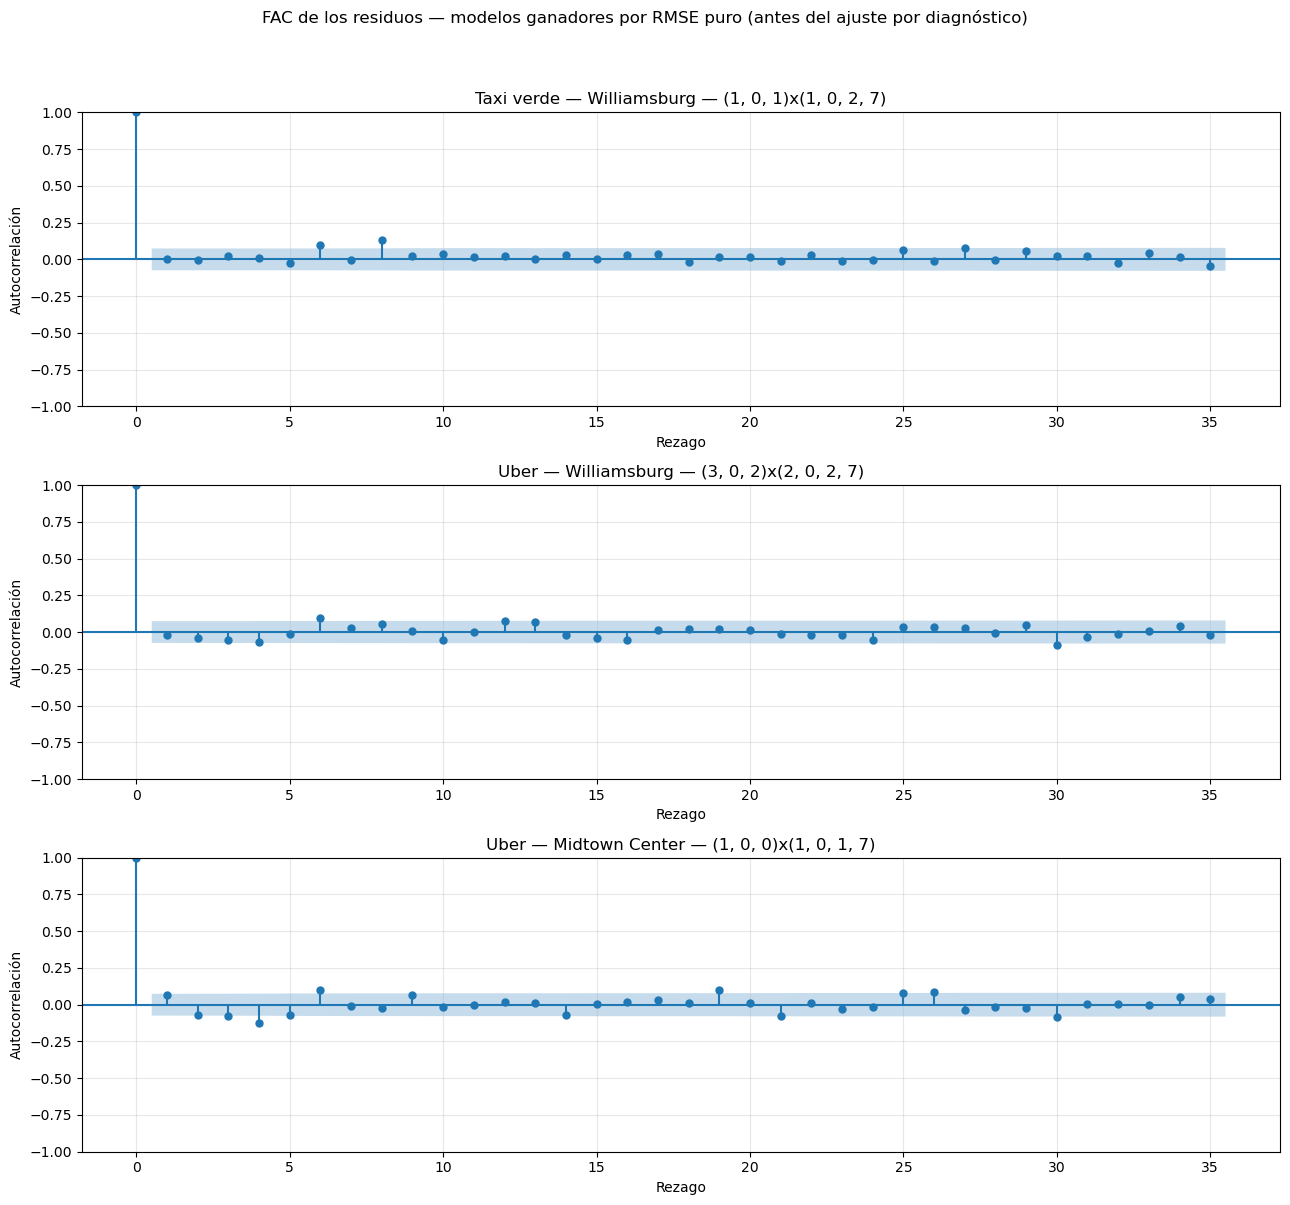

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.stats.diagnostic as sm_diagnostic

MAX_LAGS = 35


def graficar_fac_residuos(modelos, titulo):
    """Ajusta cada modelo de `modelos` sobre train y grafica la FAC de sus
    residuos. Devuelve un dict {serie: residuos} para reutilizar (p. ej. en
    el test de Ljung-Box)."""
    residuos = {}
    fig, axes = plt.subplots(3, 1, figsize=(13, 12))
    fig.suptitle(titulo, fontsize=12, y=1.0)

    for ax, (col, params) in zip(axes, modelos.items()):
        serie = df_sarimax[params['columna_serie']]
        train, test = dividir_train_test(serie)
        exog_train = exog_sarimax.loc[train.index]

        modelo = SARIMAX(
            train, exog=exog_train, order=params['order'], seasonal_order=params['seasonal_order'],
            enforce_stationarity=False, enforce_invertibility=False
        )
        fit_obj = modelo.fit(disp=False)
        residuals = fit_obj.resid
        residuos[col] = residuals

        titulo_ax = f"{columnas[col]} — {params['order']}x{params['seasonal_order']}"
        plot_acf(residuals, lags=MAX_LAGS, ax=ax, title=titulo_ax)
        ax.set_xlabel('Rezago')
        ax.set_ylabel('Autocorrelación')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    return residuos


residuos_por_serie = graficar_fac_residuos(
    mejores_modelos_sarimax,
    'FAC de los residuos — modelos ganadores por RMSE puro (antes del ajuste por diagnóstico)'
)

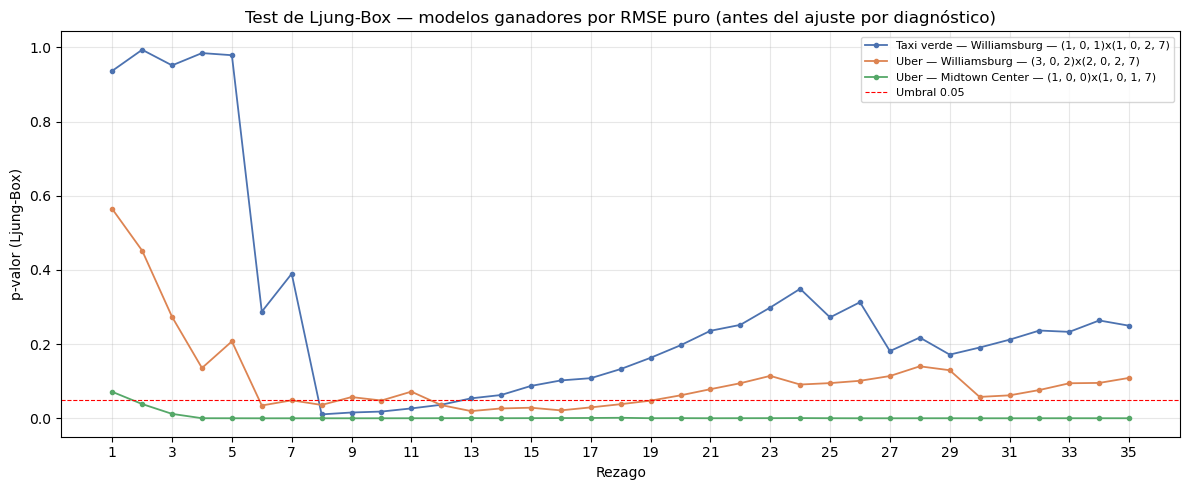

Taxi verde — Williamsburg      rezagos con p<0.05: 5/35
Uber — Williamsburg            rezagos con p<0.05: 12/35
Uber — Midtown Center          rezagos con p<0.05: 34/35


In [ ]:
colores = {
    'taxi_verde_williamsburg': '#4C72B0',
    'uber_williamsburg': '#DD8452',
    'uber_midtown': '#55A868',
}


def graficar_ljungbox(residuos, modelos, titulo):
    """Corre Ljung-Box sobre cada serie de residuos y grafica el p-valor por
    rezago. Devuelve {serie: array de p-valores}."""
    resultados = {}
    for col, residuals in residuos.items():
        if not pd.api.types.is_numeric_dtype(residuals):
            residuals = pd.to_numeric(residuals, errors='coerce').dropna()
        resultados[col] = sm_diagnostic.acorr_ljungbox(residuals, lags=MAX_LAGS)['lb_pvalue'].values

    fig, ax = plt.subplots(figsize=(12, 5))
    rezagos = range(1, MAX_LAGS + 1)
    for col, p_values in resultados.items():
        orden = modelos[col]
        etiqueta = f"{columnas[col]} — {orden['order']}x{orden['seasonal_order']}"
        ax.plot(rezagos, p_values, marker='o', markersize=3, lw=1.3, label=etiqueta, color=colores[col])

    ax.axhline(0.05, color='red', linestyle='--', lw=0.8, label='Umbral 0.05')
    ax.set_xlabel('Rezago')
    ax.set_ylabel('p-valor (Ljung-Box)')
    ax.set_title(titulo)
    ax.set_xticks(list(rezagos)[::2])
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    for col, p_values in resultados.items():
        n_rechazos = (p_values < 0.05).sum()
        print(f"{columnas[col]:30s} rezagos con p<0.05: {n_rechazos}/{MAX_LAGS}")

    return resultados


resultados_ljungbox = graficar_ljungbox(
    residuos_por_serie, mejores_modelos_sarimax,
    'Test de Ljung-Box — modelos ganadores por RMSE puro (antes del ajuste por diagnóstico)'
)

### Ajuste final por diagnóstico de residuos

El modelo de menor RMSE en test no necesariamente es el que mejor captura la estructura temporal: en las tres series aparece autocorrelación residual (particularmente severa en Uber Midtown, con 32/35 rezagos rechazando ruido blanco). Siguiendo el mismo criterio que el TP1 aplicó puntualmente sobre Uber Midtown, se amplía la búsqueda a **todos** los candidatos ya cacheados de las cuatro familias (no solo el top-3 por AIC de cada una) y se identifica, para cada serie, el candidato con residuos más cercanos a ruido blanco (menor cantidad de rezagos con p<0.05 en Ljung-Box) entre los de mejor RMSE. El resultado se compara contra el ganador "puro" por RMSE para cuantificar el costo, en términos de error, de exigir residuos limpios. La búsqueda se cachea en `data/busqueda_ljungbox_{serie}.csv` para no repetir el reajuste de docenas de modelos en cada corrida.

In [ ]:
def buscar_modelo_diagnostico_limpio(col, cfg, max_lags=MAX_LAGS, max_rechazos_aceptable=3):
    """
    Evalúa (con caché en CSV) TODOS los candidatos de las cuatro familias
    para la serie `col`: RMSE/MAE en test y cantidad de rezagos de Ljung-Box
    con p<0.05. Devuelve la tabla completa, el ganador por RMSE puro y el
    ganador por RMSE entre los que tienen a lo sumo `max_rechazos_aceptable`
    rezagos rechazados (si ninguno cumple esa cota, devuelve igualmente el
    de menos rechazos).
    """
    ruta_cache = DATA_DIR / f'busqueda_ljungbox_{col}.csv'
    columna_serie = cfg['columna_serie']

    if ruta_cache.exists():
        df_cand = pd.read_csv(ruta_cache)
        df_cand['order'] = df_cand['order'].apply(eval)
        df_cand['seasonal_order'] = df_cand['seasonal_order'].apply(eval)
    else:
        serie = df_sarimax[columna_serie]
        train, test = dividir_train_test(serie)
        exog_train = exog_sarimax.loc[train.index]
        exog_test = exog_sarimax.loc[test.index]

        test_original = None
        if columna_serie.endswith('_sqrt'):
            _, test_original = dividir_train_test(df[col])

        candidatos = pd.concat(
            [resultados_gridsearch[col][familia].assign(familia=familia) for familia in FAMILIAS],
            ignore_index=True,
        )

        filas = []
        for _, fila in candidatos.iterrows():
            try:
                modelo = SARIMAX(train, exog=exog_train, order=fila['order'], seasonal_order=fila['seasonal_order'],
                                  enforce_stationarity=False, enforce_invertibility=False)
                fit_obj = modelo.fit(disp=False)
            except Exception:
                continue

            residuals = fit_obj.resid
            if not pd.api.types.is_numeric_dtype(residuals):
                residuals = pd.to_numeric(residuals, errors='coerce').dropna()
            n_rechazos = int((sm_diagnostic.acorr_ljungbox(residuals, lags=max_lags)['lb_pvalue'] < 0.05).sum())

            pred = fit_obj.get_forecast(steps=len(test), exog=exog_test).predicted_mean
            pred.index = test.index
            if test_original is not None:
                pred_eval, objetivo_eval = pred ** 2, test_original
            else:
                pred_eval, objetivo_eval = pred, test

            filas.append({
                'familia': fila['familia'], 'order': fila['order'], 'seasonal_order': fila['seasonal_order'],
                'AIC': fila['AIC'], 'BIC': fila['BIC'], 'rechazos_lb': n_rechazos,
                'RMSE': float(np.sqrt(mean_squared_error(objetivo_eval, pred_eval))),
                'MAE': float(mean_absolute_error(objetivo_eval, pred_eval)),
            })

        df_cand = pd.DataFrame(filas)
        df_cand.to_csv(ruta_cache, index=False)

    ganador_rmse = df_cand.sort_values('RMSE').iloc[0]
    min_rechazos = df_cand['rechazos_lb'].min()
    cota = max(max_rechazos_aceptable, min_rechazos)
    ganador_limpio = df_cand[df_cand['rechazos_lb'] <= cota].sort_values('RMSE').iloc[0]

    return df_cand, ganador_rmse, ganador_limpio


filas_ajuste = []
modelos_finales_sarimax = {}

for col, cfg in configuracion_series.items():
    df_cand, ganador_rmse, ganador_limpio = buscar_modelo_diagnostico_limpio(col, cfg)

    modelos_finales_sarimax[col] = {
        'order': ganador_limpio['order'], 'seasonal_order': ganador_limpio['seasonal_order'],
        'columna_serie': cfg['columna_serie'],
    }

    filas_ajuste.append({
        'Serie': columnas[col], 'Criterio': 'RMSE puro',
        'order': ganador_rmse['order'], 'seasonal_order': ganador_rmse['seasonal_order'],
        'rechazos_lb': ganador_rmse['rechazos_lb'], 'RMSE': ganador_rmse['RMSE'], 'MAE': ganador_rmse['MAE'],
    })
    filas_ajuste.append({
        'Serie': columnas[col], 'Criterio': 'Residuos limpios (adoptado)',
        'order': ganador_limpio['order'], 'seasonal_order': ganador_limpio['seasonal_order'],
        'rechazos_lb': ganador_limpio['rechazos_lb'], 'RMSE': ganador_limpio['RMSE'], 'MAE': ganador_limpio['MAE'],
    })

df_ajuste_diagnostico = pd.DataFrame(filas_ajuste)
df_ajuste_diagnostico

,Serie,Criterio,order,seasonal_order,rechazos_lb,RMSE,MAE
0,Taxi verde — Williamsburg,RMSE puro,"(2, 0, 1)","(1, 0, 0, 7)",29,108.56,91.56
1,Taxi verde — Williamsburg,Residuos limpios (adoptado),"(1, 0, 0)","(1, 0, 1, 7)",0,116.90,75.38
2,Uber — Williamsburg,RMSE puro,"(2, 0, 1)","(1, 0, 2, 7)",35,"18,416.14","13,590.29"
3,Uber — Williamsburg,Residuos limpios (adoptado),"(3, 0, 0)","(2, 0, 1, 7)",0,"18,981.10","13,777.13"
4,Uber — Midtown Center,RMSE puro,"(3, 0, 2)","(1, 1, 0, 7)",35,"62,652.75","51,230.58"
5,Uber — Midtown Center,Residuos limpios (adoptado),"(2, 0, 2)","(2, 1, 2, 7)",0,"67,191.30","50,740.06"


In [ ]:
df_ajuste_display = df_ajuste_diagnostico.copy()
df_ajuste_display['order'] = df_ajuste_display['order'].astype(str)
df_ajuste_display['seasonal_order'] = df_ajuste_display['seasonal_order'].astype(str)

tabla_ajuste_gt = (
    GT(df_ajuste_display)
    .tab_header(
        title='Ajuste final del benchmark SARIMAX por diagnóstico de residuos',
        subtitle='RMSE puro vs. mejor modelo con residuos cercanos a ruido blanco (búsqueda sobre todos los candidatos cacheados)'
    )
    .fmt_number(columns=['RMSE', 'MAE'], decimals=2)
    .cols_label(
        order=md('Orden<br>(p,d,q)'),
        seasonal_order=md('Orden estacional<br>(P,D,Q,s)'),
        rechazos_lb=md('Rezagos<br>p&lt;0.05 (de 35)'),
    )
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_style(
        style=style.fill(color='#eafaf1'),
        locations=loc.body(rows=lambda d: d['Criterio'] == 'Residuos limpios (adoptado)')
    )
)

tabla_ajuste_gt

GT(_tbl_data=                       Serie                     Criterio      order  \
0  Taxi verde — Williamsburg                    RMSE puro  (2, 0, 1)   
1  Taxi verde — Williamsburg  Residuos limpios (adoptado)  (1, 0, 0)   
2        Uber — Williamsburg                    RMSE puro  (2, 0, 1)   
3        Uber — Williamsburg  Residuos limpios (adoptado)  (3, 0, 0)   
4      Uber — Midtown Center                    RMSE puro  (3, 0, 2)   
5      Uber — Midtown Center  Residuos limpios (adoptado)  (2, 0, 2)   

  seasonal_order  rechazos_lb      RMSE       MAE  
0   (1, 0, 0, 7)           29    108.56     91.56  
1   (1, 0, 1, 7)            0    116.90     75.38  
2   (1, 0, 2, 7)           35 18,416.14 13,590.29  
3   (2, 0, 1, 7)            0 18,981.10 13,777.13  
4   (1, 1, 0, 7)           35 62,652.75 51,230.58  
5   (2, 1, 2, 7)            0 67,191.30 50,740.06  , _body=<great_tables._gt_data.Body object at 0x000002764AC04A70>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Criterio', type=<ColInfoTypeEnum.default: 1>, column_label='Criterio', column_align='left', column_width=None), ColInfo(var='order', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Orden<br>(p,d,q)'), column_align='right', column_width=None), ColInfo(var='seasonal_order', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Orden estacional<br>(P,D,Q,s)'), column_align='right', column_width=None), ColInfo(var='rechazos_lb', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Rezagos<br>p&lt;0.05 (de 35)'), column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002764AB17CE0>, _spanners=Spanners([]), _heading=Heading(title='Ajuste final del benchmark SARIMAX por diagnóstico de residuos', subtitle='RMSE puro vs. mejor modelo con residuos cercanos a ruido blanco (búsqueda sobre todos los candidatos cacheados)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002764ABC1550>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002764ABC1C10>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=3, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=4, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, c

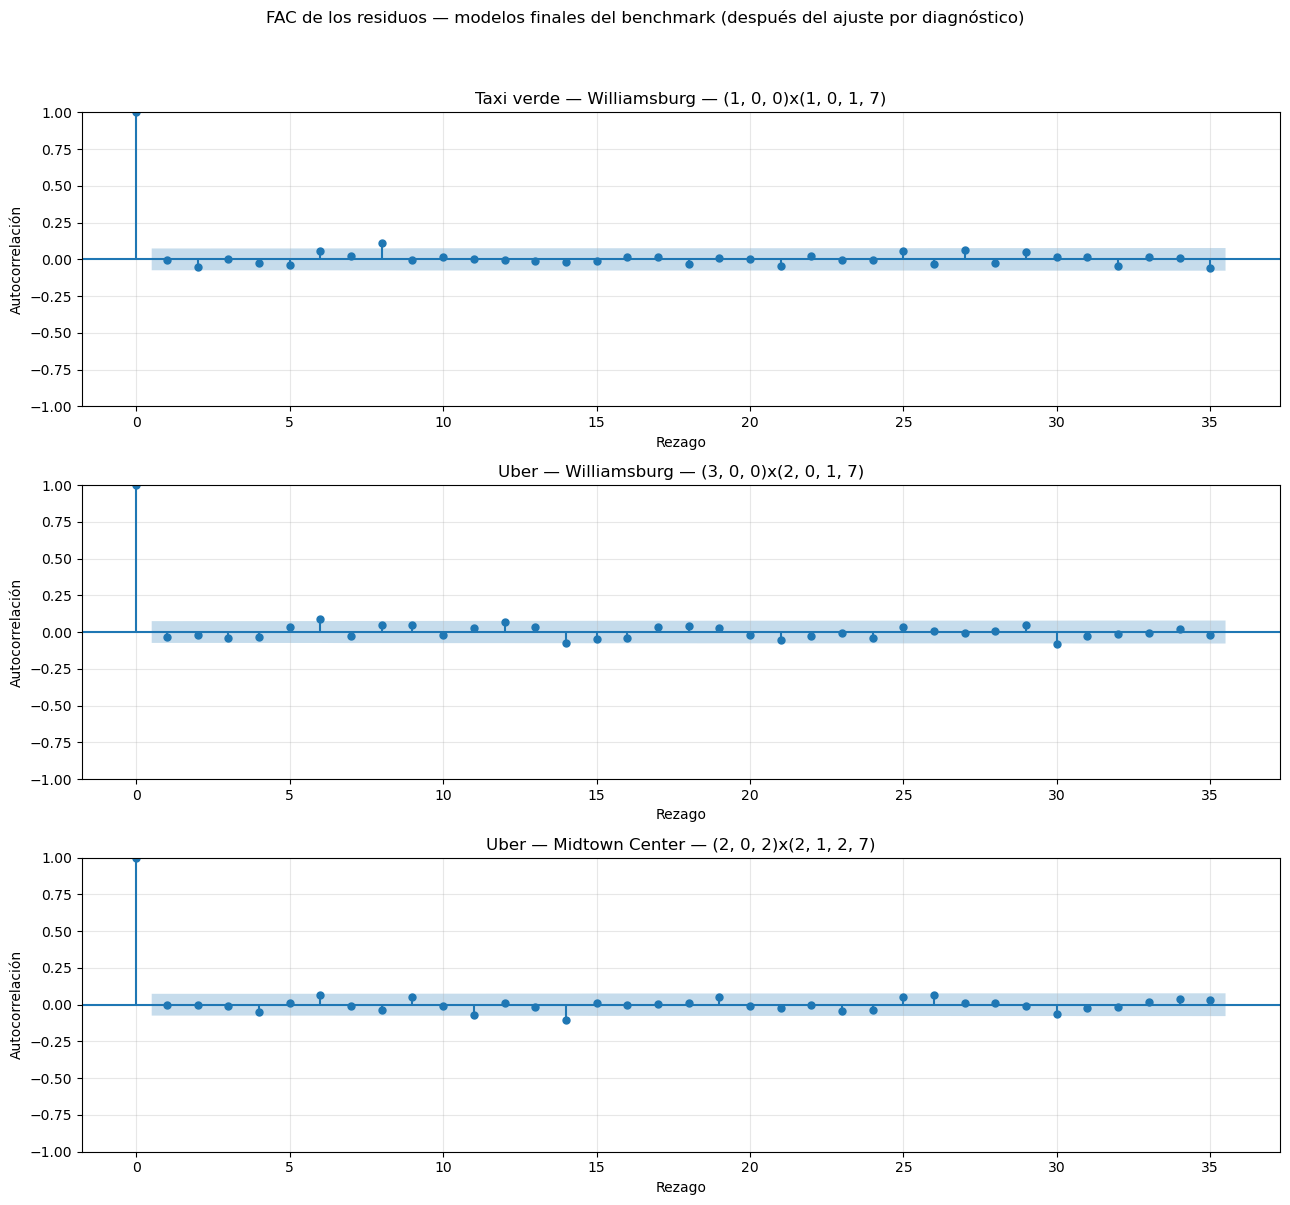

In [ ]:
residuos_finales_por_serie = graficar_fac_residuos(
    modelos_finales_sarimax,
    'FAC de los residuos — modelos finales del benchmark (después del ajuste por diagnóstico)'
)

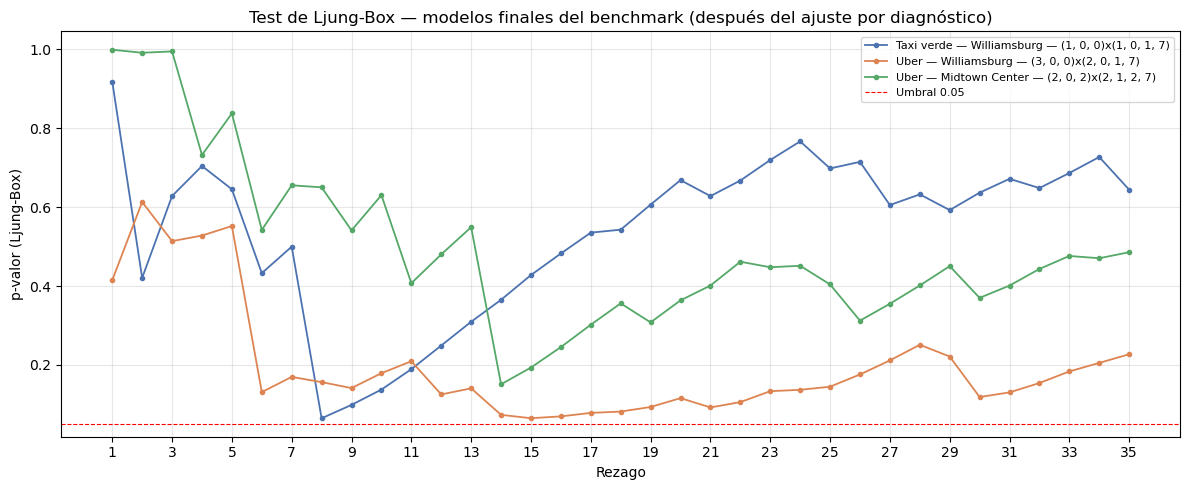

Taxi verde — Williamsburg      rezagos con p<0.05: 0/35
Uber — Williamsburg            rezagos con p<0.05: 0/35
Uber — Midtown Center          rezagos con p<0.05: 0/35


In [ ]:
resultados_ljungbox_finales = graficar_ljungbox(
    residuos_finales_por_serie, modelos_finales_sarimax,
    'Test de Ljung-Box — modelos finales del benchmark (después del ajuste por diagnóstico)'
)

Con esto queda cerrado el benchmark SARIMAX: `modelos_finales_sarimax` —y su RMSE/MAE en `df_ajuste_diagnostico`— son los que se usan más adelante como referencia estadística contra LightGBM y XGBoost. A diferencia del criterio de selección puramente por RMSE, estos modelos también superan (o se acercan mucho a superar) el test de Ljung-Box, por lo que sus intervalos de predicción y su interpretación como proceso bien especificado son más confiables.

## Modelos de Machine Learning: LightGBM y XGBoost

Se modelan las tres series con dos ensambles de árboles boosteados —**LightGBM** y **XGBoost**— usando las variables exógenas de calendario y las variables autorregresivas (rezagos y estadísticos móviles) construidas al inicio del notebook. A diferencia del SARIMAX, que modela la autocorrelación explícitamente a través de sus componentes AR/MA, estos modelos dependen enteramente de que esa estructura temporal quede expresada como *features* (`lag_k`, `rolling_mean_w`, `rolling_std_w`).

**Estrategia de validación para la búsqueda de hiperparámetros.** El conjunto de test sigue siendo el último mes calendario completo (mayo de 2026), igual que en el benchmark SARIMAX, para que la comparación final sea sobre exactamente el mismo horizonte. Para elegir los hiperparámetros de cada modelo se usa `TimeSeriesSplit(n_splits=5, test_size=30, gap=1)` de scikit-learn sobre el conjunto de train: cinco particiones con ventana de entrenamiento expansiva, cada una validando contra un bloque de 30 días consecutivos. El `gap` se fijó en 1 (prácticamente sin salto) en vez de 30: con `gap=30`, cada fold de la CV terminaba evaluando un horizonte de 31 a 60 días hacia adelante del corte de entrenamiento, mientras que el pronóstico real arranca **inmediatamente** después del último día de train (30 de abril → 1º de mayo, sin ningún salto). Un `gap` grande hacía que Optuna optimizara hiperparámetros para un problema de horizonte más largo que el que el modelo efectivamente enfrenta. Optuna minimiza el RMSE promedio de esas cinco validaciones. El mes de test nunca participa de esta búsqueda; solo se usa una vez, al final, para evaluar el modelo ya entrenado con los hiperparámetros ganadores.

Vale la pena notar una limitación que el `gap` por sí solo no resuelve: en cada fold de la CV, los rezagos y estadísticos móviles de las filas de validación se calculan a partir de valores **reales** de la serie (la tabla de *features* se arma una única vez sobre toda la serie), no de forma recursiva. Es decir, ningún fold de la CV somete al modelo a la degradación por acumulación de error que sí ocurre en el pronóstico recursivo del mes de test real; la CV mide más bien una capacidad de "predicción a un paso con información perfecta", repetida en distintos puntos del tiempo.

**Early stopping.** Ambos modelos se entrenan con `n_estimators` fijo en un techo alto (`N_ESTIMATORS_MAX = 1000`) y **early stopping** durante la CV: cada fold usa su propio bloque de validación como `eval_set` y el entrenamiento corta apenas el RMSE de validación deja de mejorar durante `EARLY_STOPPING_ROUNDS` rondas consecutivas, en vez de depender de que Optuna "adivine" el número óptimo de árboles como un hiperparámetro más. La cantidad de árboles con la que terminó cada fold se guarda como atributo del trial; al reentrenar el modelo final sobre todo el conjunto de train (donde ya no hay un bloque de validación disponible) se usa la mediana de esos valores como `n_estimators` fijo, sin early stopping en ese último ajuste.

**Pronóstico del mes de test: recursivo.** Como las variables `lag_k` y `rolling_*` dependen de valores pasados de la propia serie, no se puede simplemente "aplicar" el modelo sobre las filas de test tal como quedaron construidas más arriba (esas filas usan valores reales de mayo de 2026, que en un escenario de pronóstico genuino no están disponibles). En su lugar, se pronostica día por día: para cada fecha del mes de test se recalculan los rezagos y estadísticos móviles a partir de la serie histórica —que se va extendiendo con las predicciones ya generadas para los días anteriores del propio horizonte— y se predice el siguiente día.

**Búsqueda de hiperparámetros y caché de experimentos.** Cada corrida de Optuna se identifica por `(modelo, serie, feature_set_tag)`, donde `feature_set_tag` es un rótulo manual que agrupa una configuración particular de variables (por ejemplo, `"calendario_lags_gap1_v1"`). El estudio de Optuna correspondiente se persiste en `data/optuna/{modelo}_{serie}_{feature_set_tag}.log` usando `JournalStorage` de Optuna en vez de SQLite: la carpeta `data/` está sincronizada con Google Drive, y el locking de SQLite resultó poco confiable ahí (aparecían errores intermitentes del tipo `Record does not exist` al reanudar un estudio). `JournalStorage` con un lock basado en `open()` (en vez de symlinks, que tampoco funcionan en una unidad de Google Drive en Windows) resultó más robusto. Si se vuelve a correr con el mismo tag, Optuna retoma el estudio existente; si se cambia el tag —por ejemplo, al agregar o quitar variables— se arranca una búsqueda nueva sin pisar la anterior. Además, cada corrida agrega una fila a `data/ml_experimentos/experimentos_log.csv`, con las columnas efectivamente usadas (como un array), los hiperparámetros ganadores y las métricas de CV y de test, de modo de poder comparar experimentos entre sí más adelante.

In [ ]:
import json

import lightgbm as lgb
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import TimeSeriesSplit

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
def pronosticar_recursivo(modelo, feature_cols, serie_historica, fechas_test, exog_calendario):
    """
    Pronostica `fechas_test` día por día. `serie_historica` es la serie real
    hasta el último día de train; en cada paso se calculan los rezagos y
    estadísticos móviles a partir de esa historia (que se extiende con la
    predicción recién generada) y se predice el día siguiente.
    """
    historia = serie_historica.copy()
    predicciones = pd.Series(index=fechas_test, dtype=float)

    columnas_calendario = ['dayofyear', 'dayofmonth', 'dayofweek', 'weekofyear', 'month', 'quarter', 'year', 'holiday']

    for fecha in fechas_test:
        cal = exog_calendario.loc[fecha]
        fila = {c: cal[c] for c in columnas_calendario}

        for lag in LAGS:
            fila[f'lag_{lag}'] = historia.iloc[-lag]
        for ventana in VENTANAS_ROLLING:
            datos_ventana = historia.iloc[-ventana:]
            fila[f'rolling_mean_{ventana}'] = datos_ventana.mean()
            fila[f'rolling_std_{ventana}'] = datos_ventana.std()

        X_fila = pd.DataFrame([fila])[feature_cols]
        pred = float(modelo.predict(X_fila)[0])
        predicciones.loc[fecha] = pred
        historia.loc[fecha] = pred

    return predicciones

In [ ]:
N_SPLITS_CV = 5
TEST_SIZE_CV = 30
GAP_CV = 1
N_ESTIMATORS_MAX = 1000
EARLY_STOPPING_ROUNDS = 50


def instanciar_modelo(modelo_nombre, params, n_estimators=N_ESTIMATORS_MAX, early_stopping=False):
    """
    early_stopping=True habilita el corte temprano (requiere pasar `eval_set`
    al `.fit()` y, para XGBoost, declarar `early_stopping_rounds` en el
    constructor). Para el reentrenamiento final se llama con
    early_stopping=False y un `n_estimators` ya fijo (la mediana de los
    `best_iteration` observados en los folds de la CV), sin `eval_set`.
    """
    if modelo_nombre == 'lightgbm':
        return lgb.LGBMRegressor(**params, random_state=42, verbosity=-1, n_estimators=n_estimators)
    elif modelo_nombre == 'xgboost':
        extra = {}
        if early_stopping:
            extra['early_stopping_rounds'] = EARLY_STOPPING_ROUNDS
            extra['eval_metric'] = 'rmse'
        return xgb.XGBRegressor(**params, random_state=42, verbosity=0, n_estimators=n_estimators, **extra)
    raise ValueError(f'Modelo no reconocido: {modelo_nombre}')


def espacio_busqueda(trial, modelo_nombre):
    if modelo_nombre == 'lightgbm':
        return {
            'num_leaves': trial.suggest_int('num_leaves', 7, 31),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        }
    elif modelo_nombre == 'xgboost':
        return {
            'max_depth': trial.suggest_int('max_depth', 3, 6),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            # log=True exige low > 0; con low=0.0 Optuna tira ValueError (corregido a 1e-3)
            'gamma': trial.suggest_float('gamma', 1e-3, 5.0, log=True),
        }
    raise ValueError(f'Modelo no reconocido: {modelo_nombre}')


def objetivo_optuna(trial, modelo_nombre, X, y):
    """
    RMSE promedio de TimeSeriesSplit(n_splits=5, test_size=30, gap=1) sobre
    train, con early stopping en cada fold (usando ese mismo fold de
    validación como eval_set). El mes de test real (mayo 2026) no participa
    acá. Además guarda, como atributo del trial, la mediana de la cantidad
    de árboles con la que cada fold frenó (`mejor_n_estimators`), para
    reutilizarla al reentrenar el modelo final sobre todo train.
    """
    params = espacio_busqueda(trial, modelo_nombre)
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV, test_size=TEST_SIZE_CV, gap=GAP_CV)

    rmses = []
    mejores_iteraciones = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        modelo = instanciar_modelo(modelo_nombre, params, early_stopping=True)
        if modelo_nombre == 'lightgbm':
            modelo.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='rmse',
                       callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)])
            mejores_iteraciones.append(modelo.best_iteration_)
        else:
            modelo.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            mejores_iteraciones.append(modelo.best_iteration)

        pred = modelo.predict(X_val)
        rmses.append(np.sqrt(mean_squared_error(y_val, pred)))

    trial.set_user_attr('mejor_n_estimators', int(np.median(mejores_iteraciones)))
    return float(np.mean(rmses))

In [ ]:
from optuna.storages.journal import JournalFileBackend, JournalFileOpenLock

OPTUNA_DIR = DATA_DIR / 'optuna'
OPTUNA_DIR.mkdir(parents=True, exist_ok=True)

ML_LOG_DIR = DATA_DIR / 'ml_experimentos'
ML_LOG_DIR.mkdir(parents=True, exist_ok=True)
ML_LOG_PATH = ML_LOG_DIR / 'experimentos_log.csv'


def correr_optuna(modelo_nombre, col, feature_set_tag, X, y, n_trials):
    """
    Corre (o retoma) un estudio de Optuna, identificado por
    (modelo, serie, feature_set_tag), persistido en un archivo de log
    (`data/optuna/{...}.log`, JournalStorage) en vez de SQLite: la carpeta
    `data/` está sincronizada con Google Drive, y el locking de SQLite no
    resultó confiable ahí (aparecían errores intermitentes del tipo
    `Record does not exist` al reanudar un estudio). JournalFileBackend con
    `JournalFileOpenLock` usa un lock basado en `open()` en vez de symlinks
    (que tampoco funcionan en una unidad de Google Drive en Windows). Si el
    estudio ya tiene >= n_trials completados, no agrega trials nuevos.
    """
    nombre_estudio = f'{modelo_nombre}_{col}_{feature_set_tag}'
    ruta_log = OPTUNA_DIR / f'{nombre_estudio}.log'
    lock_obj = JournalFileOpenLock(str(ruta_log))
    storage = optuna.storages.JournalStorage(JournalFileBackend(str(ruta_log), lock_obj=lock_obj))

    study = optuna.create_study(
        study_name=nombre_estudio, storage=storage, direction='minimize',
        sampler=TPESampler(seed=42), load_if_exists=True,
    )

    trials_completados = len([t for t in study.trials if t.state.is_finished()])
    trials_pendientes = n_trials - trials_completados
    if trials_pendientes > 0:
        study.optimize(lambda trial: objetivo_optuna(trial, modelo_nombre, X, y),
                        n_trials=trials_pendientes, show_progress_bar=False)

    return study


def registrar_experimento(modelo_nombre, col, feature_set_tag, feature_cols, study, rmse_test, mae_test):
    """Agrega una fila a data/ml_experimentos/experimentos_log.csv."""
    fila = {
        'timestamp': pd.Timestamp.now().isoformat(timespec='seconds'),
        'serie': col,
        'modelo': modelo_nombre,
        'feature_set_tag': feature_set_tag,
        'n_features': len(feature_cols),
        'columnas_usadas': json.dumps(feature_cols, ensure_ascii=False),
        'mejores_hiperparametros': json.dumps(study.best_params, ensure_ascii=False),
        'mejor_n_estimators': study.best_trial.user_attrs.get('mejor_n_estimators', N_ESTIMATORS_MAX),
        'rmse_cv': study.best_value,
        'rmse_test': rmse_test,
        'mae_test': mae_test,
        'n_trials_optuna': len(study.trials),
        'optuna_study_name': study.study_name,
    }
    df_fila = pd.DataFrame([fila])
    df_fila.to_csv(ML_LOG_PATH, mode='a', header=not ML_LOG_PATH.exists(), index=False)
    return fila

### Entrenamiento, búsqueda de hiperparámetros y evaluación

Para cada serie se arma la matriz de entrenamiento a partir de `features_por_serie` (calendario + rezagos + estadísticos móviles, sin las filas iniciales con `NaN`), recortada a los datos anteriores a mayo de 2026. Sobre esa matriz corre Optuna con `TimeSeriesSplit`; con los hiperparámetros ganadores se reentrena el modelo sobre todo el train y se pronostica el mes de test de forma recursiva. `FEATURE_SET_TAG` identifica esta configuración de variables en la caché de Optuna y en el log de experimentos — cambiarlo (por ejemplo, al agregar o quitar variables) inicia una búsqueda nueva sin pisar los resultados existentes.

In [ ]:
FEATURE_SET_TAG = 'calendario_lags_gap1_v1'
N_TRIALS_OPTUNA = 100

modelos_entrenados_ml = {}    # [(modelo, serie)] -> modelo sklearn ya ajustado sobre todo train
predicciones_ml = {}          # [(modelo, serie)] -> pd.Series de predicciones recursivas en test
feature_cols_por_serie = {}   # [serie] -> lista de columnas usadas como features
X_train_por_serie = {}        # [serie] -> matriz de entrenamiento (para SHAP, importancias, etc.)
test_target_por_serie = {}    # [serie] -> pd.Series real del mes de test
resultados_ml = []

for col in columnas:
    datos = features_por_serie[col].dropna()
    _, test_target = dividir_train_test(datos[col])
    fechas_test = test_target.index
    datos_train = datos.loc[datos.index < fechas_test.min()]

    feature_cols = [c for c in datos.columns if c != col]
    X_train, y_train = datos_train[feature_cols], datos_train[col]
    serie_historica_train = df[col].loc[:fechas_test.min() - pd.Timedelta(days=1)]

    feature_cols_por_serie[col] = feature_cols
    X_train_por_serie[col] = X_train
    test_target_por_serie[col] = test_target

    print(f"\n=== {columnas[col]} === train: {len(X_train)} filas | test: {len(fechas_test)} días | features: {len(feature_cols)}")

    for modelo_nombre in ['lightgbm', 'xgboost']:
        study = correr_optuna(modelo_nombre, col, FEATURE_SET_TAG, X_train, y_train, N_TRIALS_OPTUNA)

        mejor_n_estimators = study.best_trial.user_attrs.get('mejor_n_estimators', N_ESTIMATORS_MAX)
        modelo_final = instanciar_modelo(modelo_nombre, study.best_params, n_estimators=mejor_n_estimators, early_stopping=False)
        modelo_final.fit(X_train, y_train)

        predicciones_test = pronosticar_recursivo(modelo_final, feature_cols, serie_historica_train, fechas_test, exog_calendario)

        rmse_test = float(np.sqrt(mean_squared_error(test_target, predicciones_test)))
        mae_test = float(mean_absolute_error(test_target, predicciones_test))

        registrar_experimento(modelo_nombre, col, FEATURE_SET_TAG, feature_cols, study, rmse_test, mae_test)

        modelos_entrenados_ml[(modelo_nombre, col)] = modelo_final
        predicciones_ml[(modelo_nombre, col)] = predicciones_test

        resultados_ml.append({
            'Serie': columnas[col], 'Modelo': modelo_nombre,
            'RMSE_CV': study.best_value, 'RMSE': rmse_test, 'MAE': mae_test,
            'n_estimators': mejor_n_estimators, 'n_trials': len(study.trials),
        })
        print(f"  {modelo_nombre:10s} RMSE_CV={study.best_value:,.2f}  RMSE_test={rmse_test:,.2f}  "
              f"MAE_test={mae_test:,.2f}  n_estimators={mejor_n_estimators}")

df_resultados_ml = pd.DataFrame(resultados_ml)


=== Taxi verde — Williamsburg === train: 664 filas | test: 31 días | features: 24


  lightgbm   RMSE_CV=137.99  RMSE_test=116.21  MAE_test=81.05  n_estimators=64


  xgboost    RMSE_CV=130.39  RMSE_test=131.22  MAE_test=79.69  n_estimators=314

=== Uber — Williamsburg === train: 664 filas | test: 31 días | features: 24


  lightgbm   RMSE_CV=20,659.03  RMSE_test=25,110.99  MAE_test=17,578.46  n_estimators=103


  xgboost    RMSE_CV=21,004.63  RMSE_test=22,884.89  MAE_test=16,795.20  n_estimators=312

=== Uber — Midtown Center === train: 664 filas | test: 31 días | features: 24


  lightgbm   RMSE_CV=57,115.48  RMSE_test=83,545.32  MAE_test=63,595.42  n_estimators=52


  xgboost    RMSE_CV=55,059.56  RMSE_test=87,873.72  MAE_test=64,924.43  n_estimators=157


## Comparación final: SARIMAX vs. LightGBM vs. XGBoost

Se reúnen en una sola tabla el benchmark SARIMAX (los modelos finales tras el ajuste por diagnóstico de residuos) y los dos ensambles, todos evaluados sobre el mismo conjunto de test (mayo de 2026) y en la misma escala (dólares).

In [ ]:
sarimax_final = df_ajuste_diagnostico[df_ajuste_diagnostico['Criterio'] == 'Residuos limpios (adoptado)'].copy()
sarimax_final['Modelo'] = sarimax_final.apply(
    lambda f: f"SARIMAX {f['order']}x{f['seasonal_order']}", axis=1
)
sarimax_final = sarimax_final[['Serie', 'Modelo', 'RMSE', 'MAE']]

ml_final = df_resultados_ml.copy()
ml_final['Modelo'] = ml_final['Modelo'].map({'lightgbm': 'LightGBM', 'xgboost': 'XGBoost'})
ml_final = ml_final[['Serie', 'Modelo', 'RMSE', 'MAE']]

df_comparacion_final = pd.concat([sarimax_final, ml_final], ignore_index=True).sort_values(['Serie', 'RMSE'])

tabla_final_gt = (
    GT(df_comparacion_final)
    .tab_header(
        title='Comparación final de modelos',
        subtitle='SARIMAX (benchmark) vs. LightGBM vs. XGBoost — evaluados en test (mayo 2026), en dólares'
    )
    .fmt_number(columns=['RMSE', 'MAE'], decimals=2)
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_style(
        style=style.fill(color='#eafaf1'),
        locations=loc.body(rows=lambda d: d.groupby('Serie')['RMSE'].transform('min') == d['RMSE'])
    )
)

tabla_final_gt

GT(_tbl_data=                       Serie                          Modelo      RMSE  \
3  Taxi verde — Williamsburg                        LightGBM    116.21   
0  Taxi verde — Williamsburg  SARIMAX (1, 0, 0)x(1, 0, 1, 7)    116.90   
4  Taxi verde — Williamsburg                         XGBoost    131.22   
2      Uber — Midtown Center  SARIMAX (2, 0, 2)x(2, 1, 2, 7) 67,191.30   
7      Uber — Midtown Center                        LightGBM 83,545.32   
8      Uber — Midtown Center                         XGBoost 87,873.72   
1        Uber — Williamsburg  SARIMAX (3, 0, 0)x(2, 0, 1, 7) 18,981.10   
6        Uber — Williamsburg                         XGBoost 22,884.89   
5        Uber — Williamsburg                        LightGBM 25,110.99   

        MAE  
3     81.05  
0     75.38  
4     79.69  
2 50,740.06  
7 63,595.42  
8 64,924.43  
1 13,777.13  
6 16,795.20  
5 17,578.46  , _body=<great_tables._gt_data.Body object at 0x000002764ADD0830>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002764ADD0980>, _spanners=Spanners([]), _heading=Heading(title='Comparación final de modelos', subtitle='SARIMAX (benchmark) vs. LightGBM vs. XGBoost — evaluados en test (mayo 2026), en dólares', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002764C70A960>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002764AD43A40>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=3, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=4, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=5, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=6, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), St

## Análisis de los modelos de Machine Learning

Se cierra la comparación con un conjunto de diagnósticos sobre LightGBM y XGBoost, orientados a entender qué aprendió cada modelo y dónde falla: importancia de variables (nativa y SHAP), comparación entre el error de validación cruzada (CV) y el error real de test, y un análisis específico del pronóstico recursivo —real vs. predicho y error según el día del horizonte— para evaluar si el error se acumula a medida que avanza el mes pronosticado, tal como se conjeturó al comparar contra el benchmark SARIMAX.

### Importancia de variables (nativa)

Importancia nativa de cada modelo (basada en la ganancia/uso de cada variable para partir los árboles), para las tres series y los dos modelos.

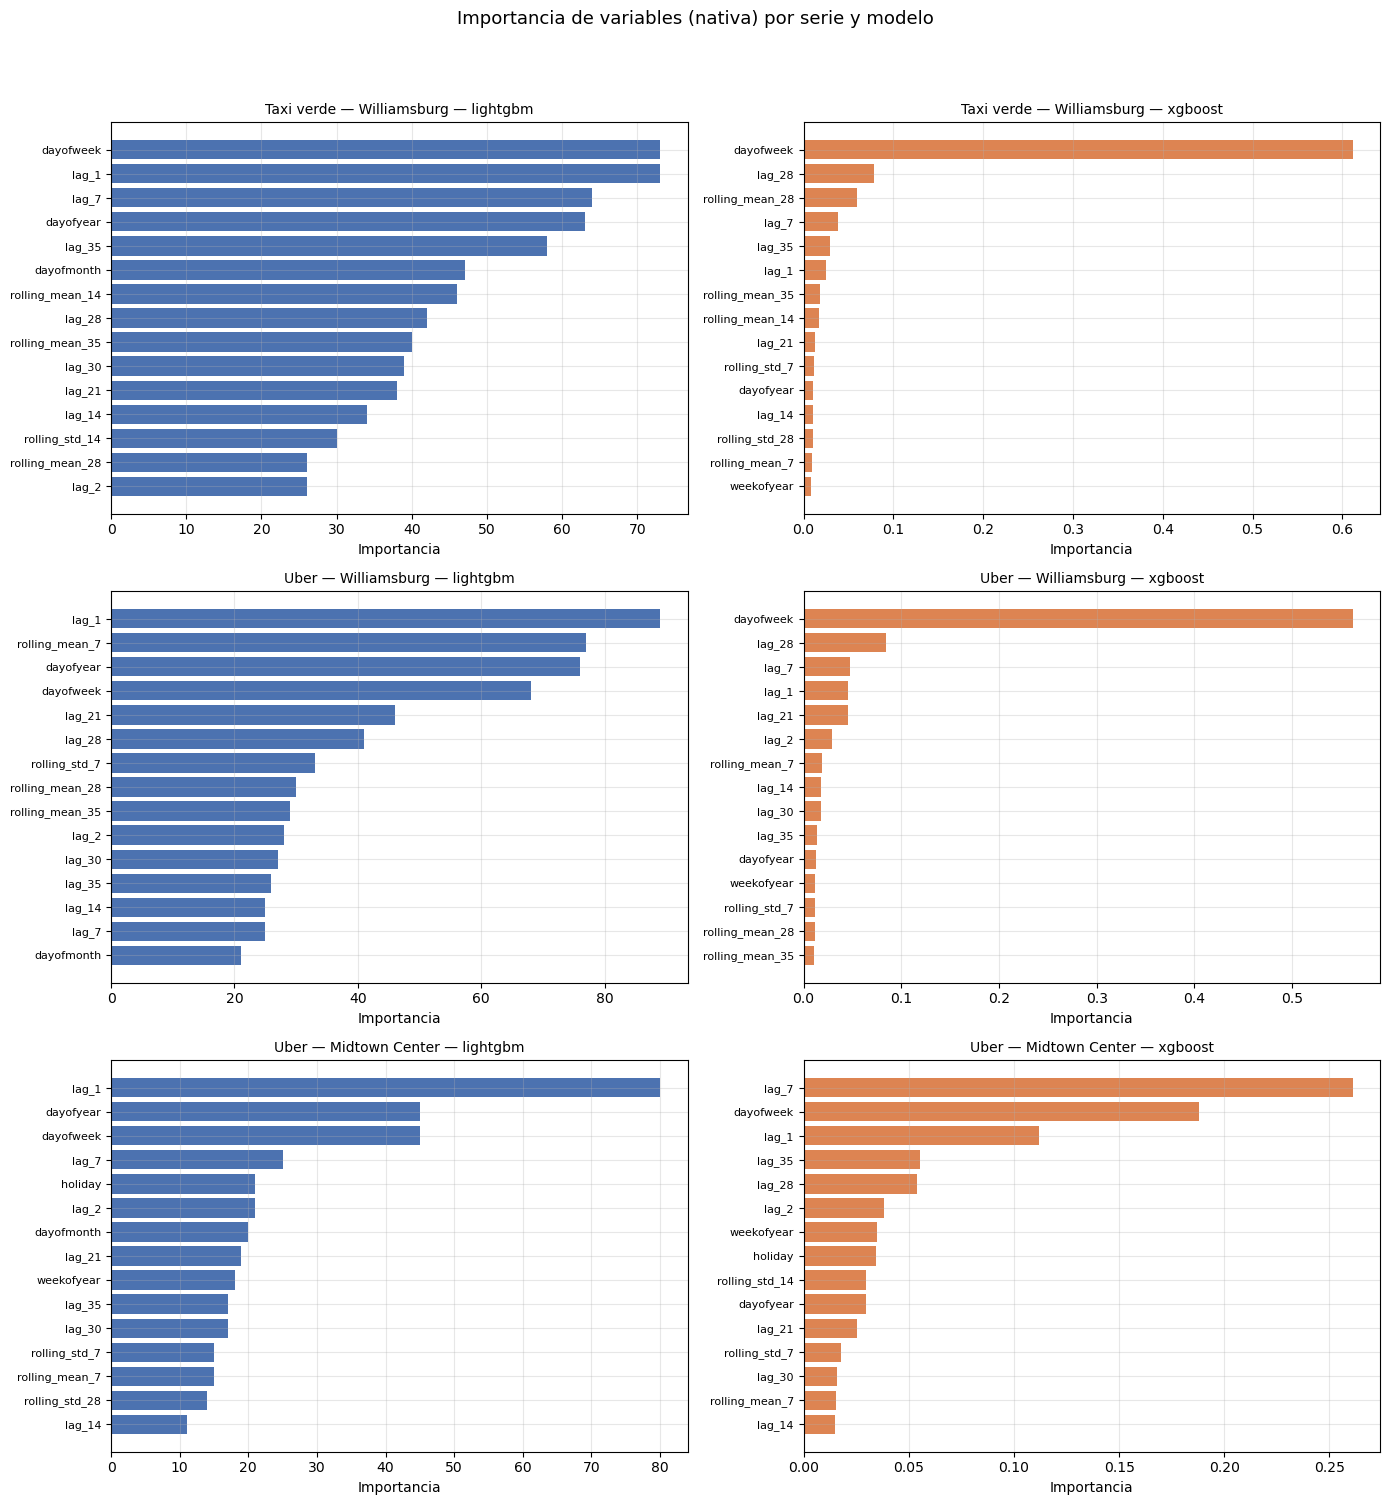

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle('Importancia de variables (nativa) por serie y modelo', fontsize=13, y=1.0)

colores_modelo = {'lightgbm': '#4C72B0', 'xgboost': '#DD8452'}

for i, col in enumerate(columnas):
    for j, modelo_nombre in enumerate(['lightgbm', 'xgboost']):
        ax = axes[i, j]
        modelo = modelos_entrenados_ml[(modelo_nombre, col)]
        importancias = pd.Series(modelo.feature_importances_, index=feature_cols_por_serie[col])
        importancias = importancias.sort_values(ascending=True).tail(15)

        ax.barh(importancias.index, importancias.values, color=colores_modelo[modelo_nombre])
        ax.set_title(f"{columnas[col]} — {modelo_nombre}", fontsize=10)
        ax.set_xlabel('Importancia')
        ax.tick_params(axis='y', labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### SHAP: contribución de cada variable a las predicciones

A diferencia de la importancia nativa (que resume cuánto se usó cada variable en promedio, sin indicar la dirección del efecto), los valores SHAP muestran, para cada observación de train, cuánto empujó cada variable la predicción hacia arriba o hacia abajo. Se calcula solo para el modelo con menor RMSE de test en cada serie (entre LightGBM y XGBoost), para no multiplicar la cantidad de gráficos.

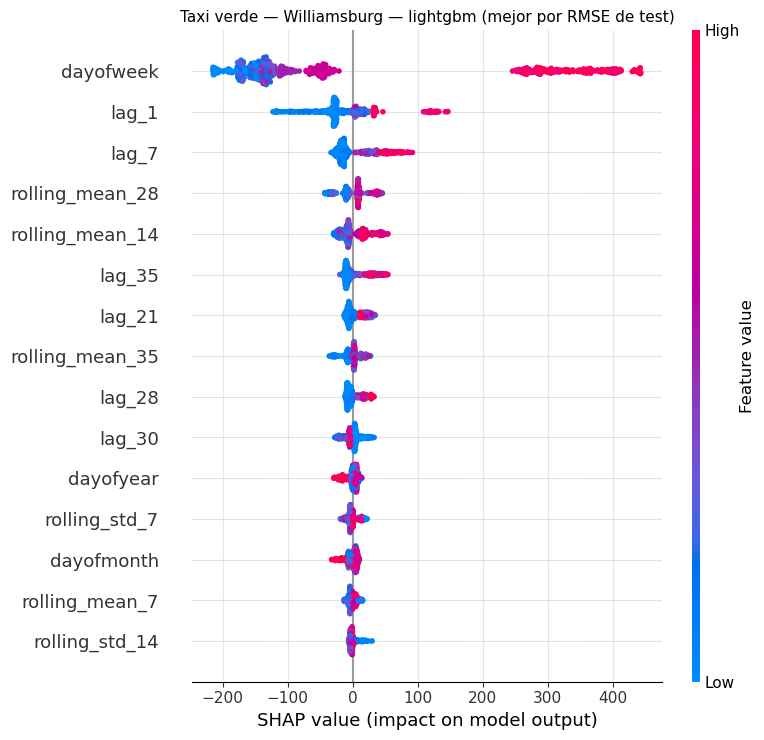

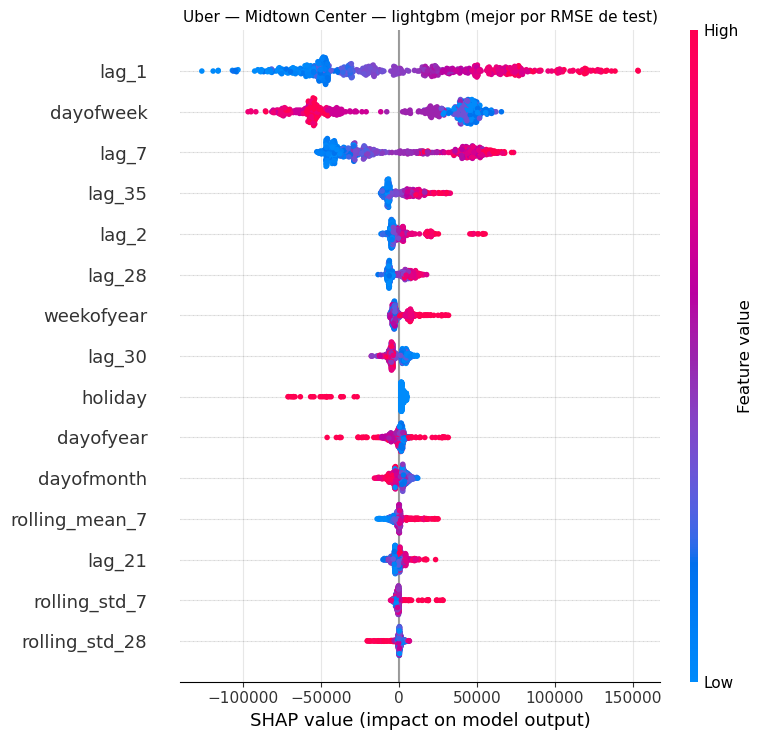

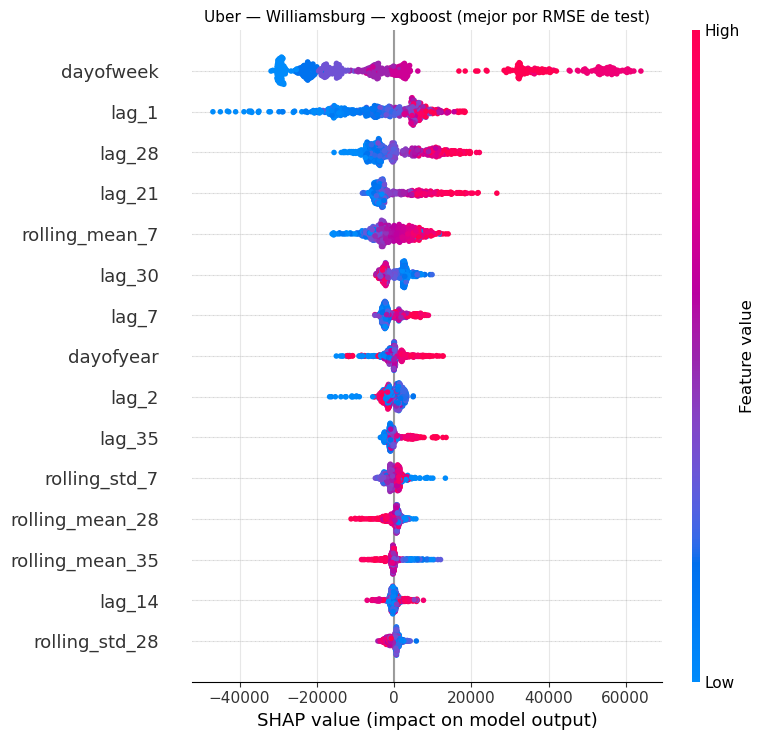

In [ ]:
import shap

inv_columnas = {v: k for k, v in columnas.items()}
mejor_ml_por_serie = df_resultados_ml.sort_values(['Serie', 'RMSE']).groupby('Serie').first()

resultados_shap = {}
for serie_display, fila in mejor_ml_por_serie.iterrows():
    col = inv_columnas[serie_display]
    modelo_nombre = fila['Modelo']
    modelo = modelos_entrenados_ml[(modelo_nombre, col)]
    X_tr = X_train_por_serie[col]

    explainer = shap.TreeExplainer(modelo)
    shap_values = explainer.shap_values(X_tr)
    resultados_shap[col] = shap_values

    plt.figure()
    shap.summary_plot(shap_values, X_tr, show=False, max_display=15)
    plt.title(f"{serie_display} — {modelo_nombre} (mejor por RMSE de test)", fontsize=11)
    plt.tight_layout()
    plt.show()

### RMSE de validación (CV) vs. RMSE de test

Compara, para cada combinación de serie y modelo, el RMSE promedio de los 5 folds de `TimeSeriesSplit` que usó Optuna para elegir hiperparámetros contra el RMSE real obtenido sobre mayo de 2026. Un `gap_relativo` grande y positivo indica que el modelo generalizó peor al mes de test real de lo que la CV hacía prever —una señal de que la CV (que nunca ejercita el pronóstico recursivo) es un proxy imperfecto del desempeño real—.

In [ ]:
df_cv_vs_test = df_resultados_ml.copy()
df_cv_vs_test['gap_relativo_%'] = 100 * (df_cv_vs_test['RMSE'] - df_cv_vs_test['RMSE_CV']) / df_cv_vs_test['RMSE_CV']

tabla_cv_test_gt = (
    GT(df_cv_vs_test[['Serie', 'Modelo', 'RMSE_CV', 'RMSE', 'gap_relativo_%']])
    .tab_header(
        title='RMSE de validación (CV) vs. RMSE de test',
        subtitle='gap_relativo = 100 x (RMSE_test - RMSE_CV) / RMSE_CV'
    )
    .fmt_number(columns=['RMSE_CV', 'RMSE'], decimals=2)
    .fmt_number(columns=['gap_relativo_%'], decimals=1)
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_style(
        style=style.fill(color='#fdecea'),
        locations=loc.body(rows=lambda d: d['gap_relativo_%'] > 20)
    )
)

tabla_cv_test_gt

GT(_tbl_data=                       Serie    Modelo   RMSE_CV      RMSE  gap_relativo_%
0  Taxi verde — Williamsburg  lightgbm    137.99    116.21          -15.78
1  Taxi verde — Williamsburg   xgboost    130.39    131.22            0.63
2        Uber — Williamsburg  lightgbm 20,659.03 25,110.99           21.55
3        Uber — Williamsburg   xgboost 21,004.63 22,884.89            8.95
4      Uber — Midtown Center  lightgbm 57,115.48 83,545.32           46.27
5      Uber — Midtown Center   xgboost 55,059.56 87,873.72           59.60, _body=<great_tables._gt_data.Body object at 0x000002764F044080>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='RMSE_CV', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE_CV', column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='gap_relativo_%', type=<ColInfoTypeEnum.default: 1>, column_label='gap_relativo_%', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002764F060F80>, _spanners=Spanners([]), _heading=Heading(title='RMSE de validación (CV) vs. RMSE de test', subtitle='gap_relativo = 100 x (RMSE_test - RMSE_CV) / RMSE_CV', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002764C22B050>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002764C1133B0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=3, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=4, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=5, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=<function <lambda> at 0x000002764C210680>, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleFill(color='#fdecea')]), StyleInfo(locname=LocBody(columns=None, rows=<function <lambda> at 0x000002764C210680>, mask=None), grpname=None, colname='Serie', rownum=4, colnum=None, styles=[CellStyleFill(color='#fdecea')]), StyleInfo(locname=LocBody(columns=None, rows=<function <lambda> at 0x000002764C210680>, mask=None), grpname=None, colname='Serie', rownum=

### Pronóstico recursivo: real vs. predicho, y error según el día del horizonte

El panel izquierdo compara la serie real de mayo de 2026 contra las predicciones recursivas de LightGBM y XGBoost. El panel derecho grafica el error absoluto en función del día del horizonte (día 1 = primer día pronosticado, inmediatamente después de train; día 31 = último día del mes). Si el pronóstico recursivo efectivamente acumula error a medida que se aleja del último dato real, debería verse una tendencia creciente en el panel derecho.

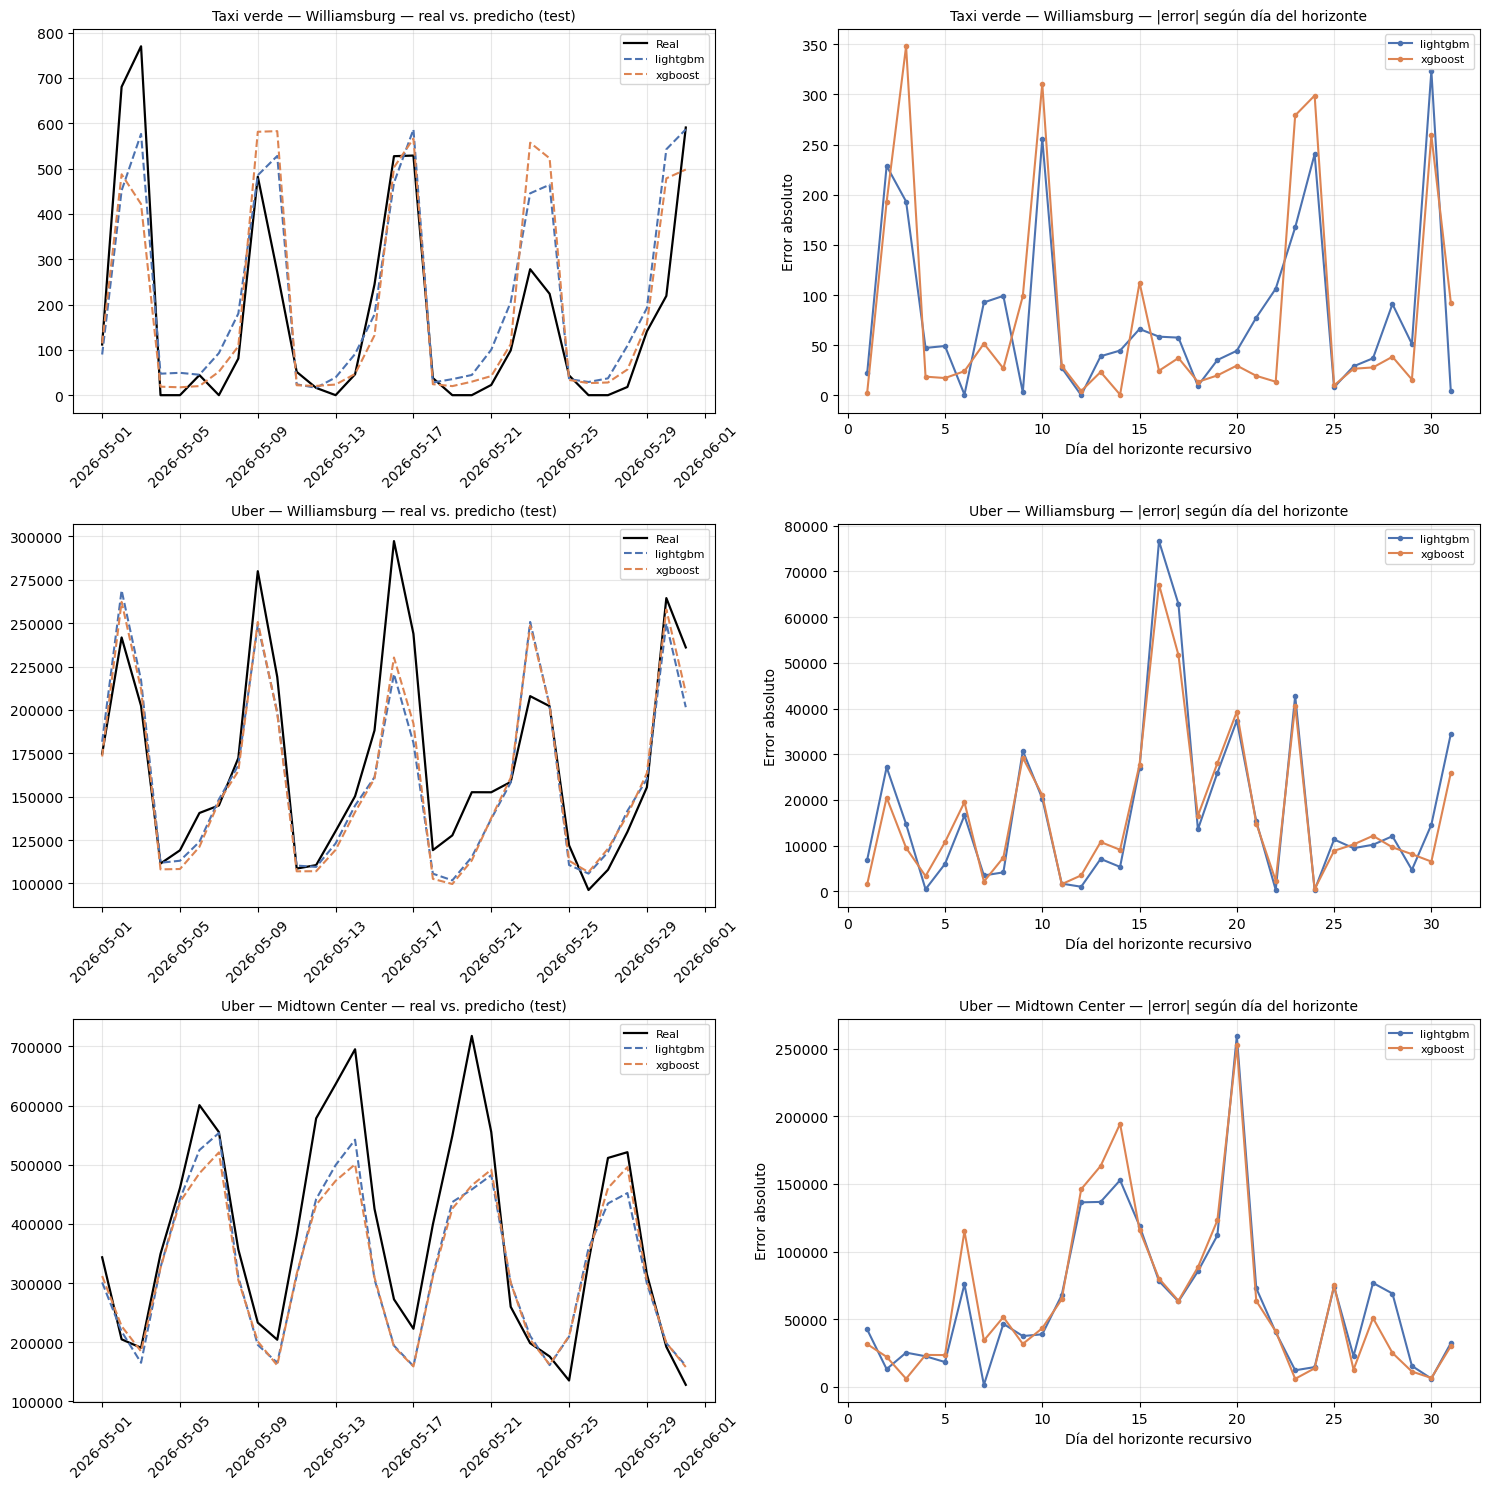

Correlación entre el día del horizonte y el error absoluto (cercana a +1 = el error crece con el horizonte):


,Serie,Modelo,correlacion_dia_vs_error_abs
0,Taxi verde — Williamsburg,lightgbm,0.04
1,Taxi verde — Williamsburg,xgboost,-0.01
2,Uber — Midtown Center,lightgbm,0.05
3,Uber — Midtown Center,xgboost,-0.06
4,Uber — Williamsburg,lightgbm,0.11
5,Uber — Williamsburg,xgboost,0.10


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

resumen_horizonte = []

for i, col in enumerate(columnas):
    test_target = test_target_por_serie[col]
    ax_izq, ax_der = axes[i]

    ax_izq.plot(test_target.index, test_target.values, label='Real', color='black', lw=1.6)
    for modelo_nombre in ['lightgbm', 'xgboost']:
        pred = predicciones_ml[(modelo_nombre, col)]
        ax_izq.plot(pred.index, pred.values, label=modelo_nombre, linestyle='--', color=colores_modelo[modelo_nombre])
    ax_izq.set_title(f"{columnas[col]} — real vs. predicho (test)", fontsize=10)
    ax_izq.legend(fontsize=8)
    ax_izq.tick_params(axis='x', rotation=45)

    for modelo_nombre in ['lightgbm', 'xgboost']:
        pred = predicciones_ml[(modelo_nombre, col)]
        error_abs = (pred - test_target).abs()
        dias_horizonte = range(1, len(error_abs) + 1)
        ax_der.plot(list(dias_horizonte), error_abs.values, marker='o', markersize=3,
                    label=modelo_nombre, color=colores_modelo[modelo_nombre])
        for d, e in zip(dias_horizonte, error_abs.values):
            resumen_horizonte.append({
                'Serie': columnas[col], 'Modelo': modelo_nombre,
                'dia_horizonte': d, 'error_abs': e,
            })
    ax_der.set_title(f"{columnas[col]} — |error| según día del horizonte", fontsize=10)
    ax_der.set_xlabel('Día del horizonte recursivo')
    ax_der.set_ylabel('Error absoluto')
    ax_der.legend(fontsize=8)

plt.tight_layout()
plt.show()

df_resumen_horizonte = pd.DataFrame(resumen_horizonte)

correlaciones_horizonte = (
    df_resumen_horizonte.groupby(['Serie', 'Modelo'])
    .apply(lambda g: g['dia_horizonte'].corr(g['error_abs']), include_groups=False)
    .rename('correlacion_dia_vs_error_abs')
    .reset_index()
)
print('Correlación entre el día del horizonte y el error absoluto (cercana a +1 = el error crece con el horizonte):')
correlaciones_horizonte

### Residuos del mejor modelo de cada serie: normalidad y heterocedasticidad

QQ plot (¿los residuos del pronóstico de test se parecen a una normal?) y residuos vs. predicho (¿hay heterocedasticidad, es decir, mayor dispersión del error para niveles predichos más altos o más bajos?), para el modelo con menor RMSE de test en cada serie.

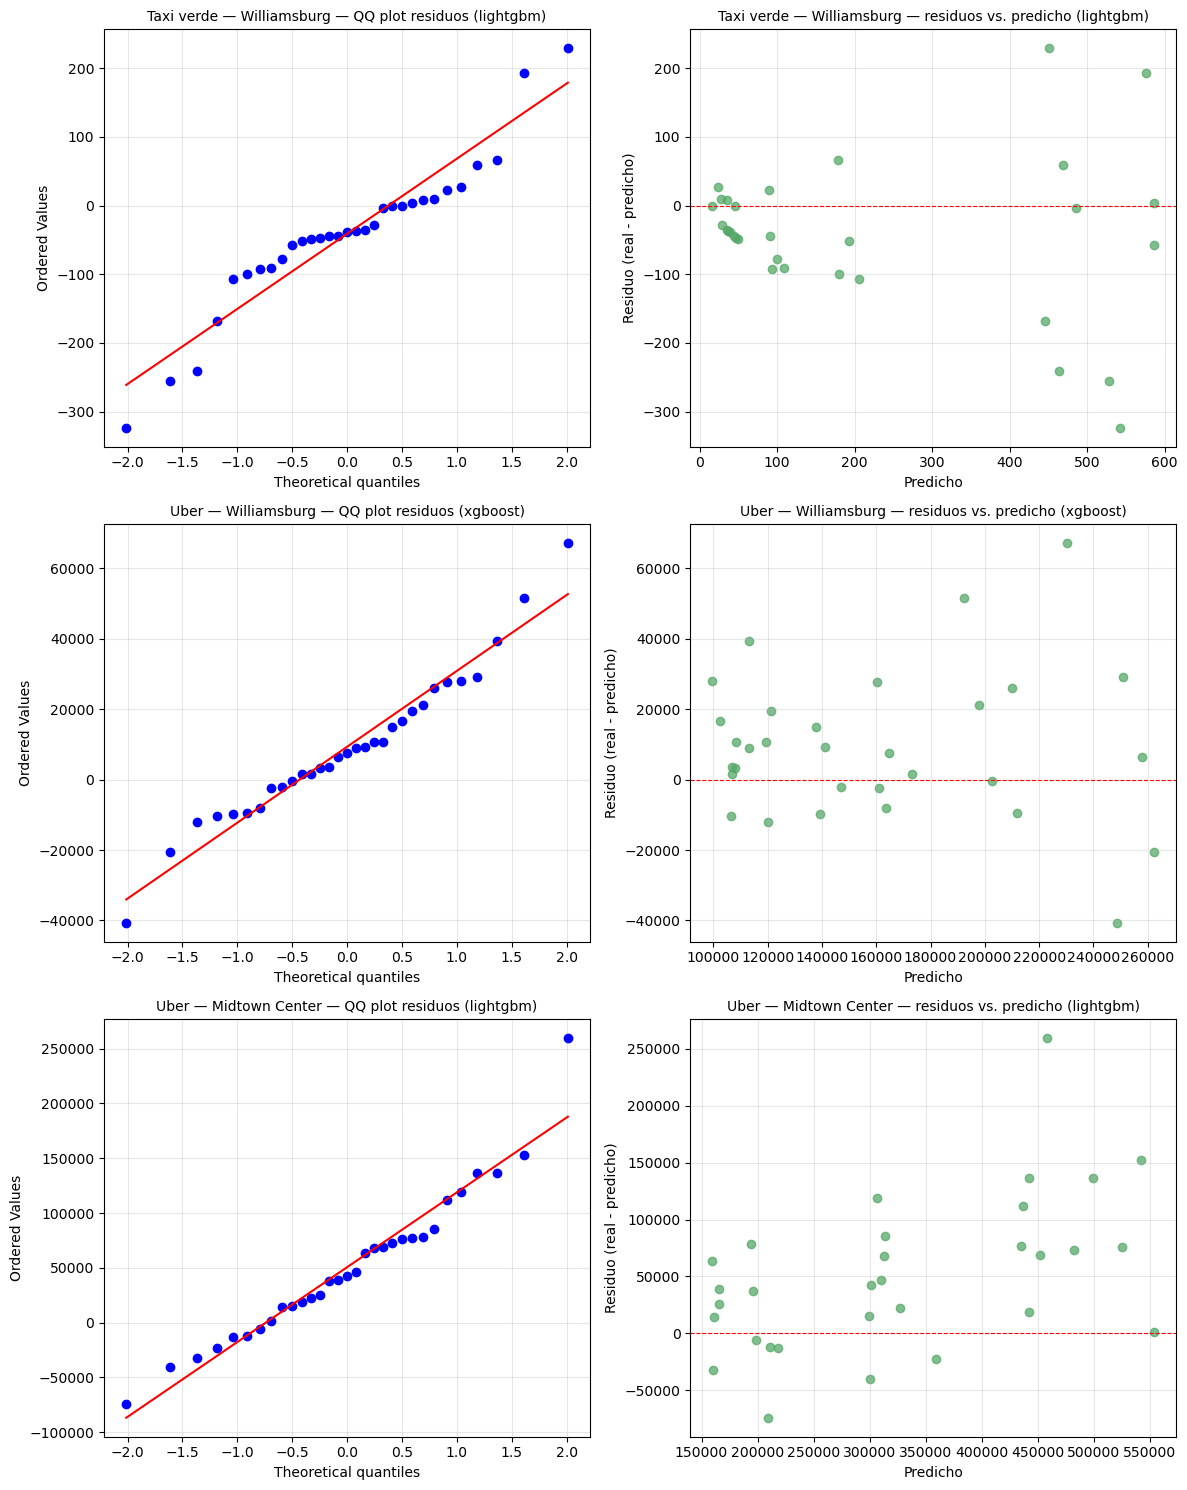

In [ ]:
from scipy import stats

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for i, col in enumerate(columnas):
    serie_display = columnas[col]
    modelo_nombre = mejor_ml_por_serie.loc[serie_display, 'Modelo']
    test_target = test_target_por_serie[col]
    pred = predicciones_ml[(modelo_nombre, col)]
    residuos = test_target - pred

    ax_qq, ax_resid = axes[i]

    stats.probplot(residuos, dist='norm', plot=ax_qq)
    ax_qq.set_title(f"{serie_display} — QQ plot residuos ({modelo_nombre})", fontsize=10)

    ax_resid.scatter(pred, residuos, alpha=0.75, color='#55A868')
    ax_resid.axhline(0, color='red', linestyle='--', lw=0.8)
    ax_resid.set_xlabel('Predicho')
    ax_resid.set_ylabel('Residuo (real - predicho)')
    ax_resid.set_title(f"{serie_display} — residuos vs. predicho ({modelo_nombre})", fontsize=10)

plt.tight_layout()
plt.show()